# Algoritmo neuronal APS - GNN compatible para comparacion

Esta version conserva la preparacion de datos, calendario, recursos, rutas y decodificador del notebook `aps_genetico.ipynb`.

A partir de la seccion del algoritmo se sustituye el AG por un enfoque neuronal inspirado en el bloque de redes neuronales de `informe_algoritmos.txt`:

- Duraciones de operacion fijas por formula CCP, identicas a `aps_ensemble.ipynb`.
- GNN sobre un grafo orden-partnumber-recurso-operacion para estimar riesgo de tardanza por orden.
- Politica de prioridad neural que ordena las ordenes antes de decodificar el plan con las mismas restricciones duras.
- Exportacion de resultados, validacion, metricas por orden/recurso y comparativas equivalentes al notebook genetico.

Los archivos generados usan prefijo `nn_` para facilitar la comparacion futura con los resultados `ga_` y `ens_`.


## 1. Imports y configuración

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from collections import OrderedDict, defaultdict
import math
import random
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 2. Resolución robusta de rutas

In [2]:
def resolver_carpeta_ejecucion():
    """Devuelve la carpeta del archivo/notebook que se está ejecutando."""
    archivo_actual = globals().get("__file__")
    if archivo_actual and Path(archivo_actual).exists():
        return Path(archivo_actual).resolve().parent

    notebook_name = "aps_neuronal.ipynb"
    cwd = Path.cwd().resolve()
    candidatos = [cwd / notebook_name, cwd / "tfm" / "algoritmos" / notebook_name]
    try:
        candidatos.extend(cwd.glob(f"**/{notebook_name}"))
    except OSError:
        pass

    for ruta in candidatos:
        if ruta.exists():
            return ruta.resolve().parent
    return cwd


def resolver_rutas():
    """Localiza los CSV desde la carpeta del codigo, su padre y rutas conocidas."""
    carpeta_codigo = resolver_carpeta_ejecucion()
    candidatos_raiz = [
        carpeta_codigo,
        carpeta_codigo.parent,
        Path("/workspace/tfm"),
        Path("/opt/projects/tfm"),
        Path("/workspace/projects/tfm"),
        Path("/mnt/data"),
        Path.cwd(),
    ]
    subdirs_datos = ["datos_ofuscados", ""]
    output_dir = carpeta_codigo / "output"

    for raiz in candidatos_raiz:
        for sub in subdirs_datos:
            data_dir = raiz / sub if sub else raiz
            if (data_dir / "PLAN.csv").exists() and (data_dir / "CCP.csv").exists():
                return raiz, data_dir, output_dir
    raise FileNotFoundError("No se encontraron PLAN.csv y CCP.csv en las rutas esperadas.")

ROOT_DIR, DATA_DIR, OUTPUT_DIR = resolver_rutas()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLAN_PATH = DATA_DIR / "PLAN.csv"
CCP_PATH = DATA_DIR / "CCP.csv"
LPA_GAM_PATH = DATA_DIR / "LPA_GAM.csv" if (DATA_DIR / "LPA_GAM.csv").exists() else ROOT_DIR / "LPA_GAM.csv"
LPA_GSM_PATH = DATA_DIR / "LPA_GSM.csv" if (DATA_DIR / "LPA_GSM.csv").exists() else ROOT_DIR / "LPA_GSM.csv"

print("ROOT_DIR :", ROOT_DIR)
print("DATA_DIR :", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PLAN     :", PLAN_PATH)
print("CCP      :", CCP_PATH)
print("LPA_GAM  :", LPA_GAM_PATH)
print("LPA_GSM  :", LPA_GSM_PATH)

ROOT_DIR : /opt/projects/tfm
DATA_DIR : /opt/projects/tfm/datos_ofuscados
OUTPUT_DIR: /opt/projects/tfm/algoritmos/output
PLAN     : /opt/projects/tfm/datos_ofuscados/PLAN.csv
CCP      : /opt/projects/tfm/datos_ofuscados/CCP.csv
LPA_GAM  : /opt/projects/tfm/datos_ofuscados/LPA_GAM.csv
LPA_GSM  : /opt/projects/tfm/datos_ofuscados/LPA_GSM.csv


## 3. Carga y primera inspección de datos

In [3]:
def leer_csv(path, **kwargs):
    return pd.read_csv(path, sep=";", encoding="utf-8-sig", **kwargs)

plan_df = leer_csv(
    PLAN_PATH,
    parse_dates=["FECHA_PROVEEDOR", "FECHA_ENTREGA"],
)
ccp_df = leer_csv(CCP_PATH)
lpa_gam = leer_csv(
    LPA_GAM_PATH,
    parse_dates=["COMIENZO_OPERACION", "FIN_OPERACION", "FECHA_CALCULO_PLAN"],
)
lpa_gsm = leer_csv(
    LPA_GSM_PATH,
    parse_dates=["COMIENZO_OPERACION", "FIN_OPERACION", "FECHA_CALCULO_PLAN"],
)
lpa_df = pd.concat([lpa_gam, lpa_gsm], ignore_index=True)

print("PLAN:", plan_df.shape)
print("CCP :", ccp_df.shape)
print("LPA :", lpa_df.shape)
print("\nColumnas PLAN:", list(plan_df.columns))
print("Columnas CCP :", list(ccp_df.columns))
print("Columnas LPA :", list(lpa_df.columns))

PLAN: (14983, 8)
CCP : (35789, 10)
LPA : (12829, 13)

Columnas PLAN: ['ORDEN', 'PARTNUMBER', 'CANTIDAD', 'CENTRO', 'FECHA_PROVEEDOR', 'FECHA_PROVEEDOR_REAL', 'FECHA_ENTREGA', 'CLIENTE']
Columnas CCP : ['PARTNUMBER', 'OPERACION', 'POSTURA', 'RECURSO', 'TECNOLOGIA', 'CENTRO_MECANIZADO', 'PIEZAS_SIMULTANEAS', 'TIEMPO_FIJO_MIN', 'TIEMPO_VARIABLE_MIN', 'OEE']
Columnas LPA : ['ORDEN', 'OPERACION', 'RECURSO', 'PARTNUMBER', 'CANTIDAD', 'COMIENZO_OPERACION', 'FIN_OPERACION', 'TIEMPO_PREPARACION', 'TIEMPO_PROCESO', 'GRUPO_RECURSO', 'MULTIPLICIDAD', 'DURACION_CCP', 'FECHA_CALCULO_PLAN']


## 4. Limpieza de órdenes sin datos CCP, sin tiempos CCP o sin OEE

Limpieza de órdenes con fecha de proveedor en atraso configurable (por defecto, True)

In [4]:
# Parametros configurables del alcance de planificacion.
# MODO_PLANIFICACION_ORDENES:
# - "TODAS": planifica todas las ordenes de PLAN que superen la limpieza de datos.
# - "SOLO_LPA": planifica solo las ordenes de PLAN cuyo codigo ORDEN aparece en LPA_GAM o LPA_GSM.
MODO_PLANIFICACION_ORDENES = "SOLO_LPA"
ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA = True
FECHA_REFERENCIA_ATRASO_PROVEEDOR = pd.Timestamp(lpa_df["FECHA_CALCULO_PLAN"].dropna().min()).floor("D")

MODOS_PLANIFICACION_VALIDOS = {"TODAS", "SOLO_LPA"}
if MODO_PLANIFICACION_ORDENES not in MODOS_PLANIFICACION_VALIDOS:
    raise ValueError(
        "MODO_PLANIFICACION_ORDENES debe ser uno de "
        f"{sorted(MODOS_PLANIFICACION_VALIDOS)}"
    )

# Primero se detectan los PARTNUMBER cuya ruta CCP no es utilizable.
# Se invalidan si alguna operacion no tiene tiempos u OEE usable.
tiempo_cols = ["TIEMPO_FIJO_MIN", "TIEMPO_VARIABLE_MIN"]
tiempos_ccp = ccp_df[tiempo_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", ".", regex=False), errors="coerce")
)
oee_ccp = pd.to_numeric(
    ccp_df["OEE"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)

partnumber_ccp = ccp_df["PARTNUMBER"].astype("string")
partnumbers_ccp = set(partnumber_ccp.dropna().astype(str))
mascara_ccp_tiempo_cero = tiempos_ccp.fillna(0.0).sum(axis=1).le(0.0)
mascara_ccp_oee_invalido = oee_ccp.isna() | oee_ccp.eq(0)
partnumbers_ccp_tiempo_cero = set(
    partnumber_ccp[mascara_ccp_tiempo_cero & partnumber_ccp.notna()].astype(str)
)
partnumbers_ccp_oee_invalido = set(
    partnumber_ccp[mascara_ccp_oee_invalido & partnumber_ccp.notna()].astype(str)
)
partnumbers_ccp_validos = partnumbers_ccp - partnumbers_ccp_tiempo_cero - partnumbers_ccp_oee_invalido

# Despues se filtran las ordenes de PLAN antes de ejecutar cualquier parte del algoritmo.
# Primero se aplica el alcance elegido: todas las ordenes o solo las ya presentes en LPA.
n_plan_original = len(plan_df)
ordenes_lpa = set(lpa_df["ORDEN"].dropna().astype(str))
orden_plan = plan_df["ORDEN"].astype("string")
mascara_plan_en_lpa = orden_plan.notna() & orden_plan.astype(str).isin(ordenes_lpa)
n_ordenes_plan_fuera_lpa = int((~mascara_plan_en_lpa).sum())
ordenes_plan_fuera_lpa = plan_df.loc[
    ~mascara_plan_en_lpa,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_fuera_lpa["MOTIVO"] = "ORDEN no aparece en LPA_GAM ni LPA_GSM"

if MODO_PLANIFICACION_ORDENES == "SOLO_LPA":
    plan_df = plan_df.loc[mascara_plan_en_lpa].reset_index(drop=True)
else:
    ordenes_plan_fuera_lpa = ordenes_plan_fuera_lpa.iloc[0:0].copy()

# Se eliminan las ordenes sin datos CCP, con tiempos CCP a cero o con OEE CCP sin valor/cero.
partnumber_plan = plan_df["PARTNUMBER"].astype("string")
mascara_plan_con_ccp = partnumber_plan.notna() & partnumber_plan.isin(partnumbers_ccp)
mascara_plan_con_ccp_valido = partnumber_plan.notna() & partnumber_plan.isin(partnumbers_ccp_validos)
mascara_plan_ccp_tiempo_cero = mascara_plan_con_ccp & partnumber_plan.isin(partnumbers_ccp_tiempo_cero)
mascara_plan_ccp_oee_invalido = mascara_plan_con_ccp & partnumber_plan.isin(partnumbers_ccp_oee_invalido)

ordenes_plan_sin_ccp = plan_df.loc[
    ~mascara_plan_con_ccp,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_sin_ccp["MOTIVO"] = "PARTNUMBER no aparece en CCP"

ordenes_plan_ccp_tiempo_cero = plan_df.loc[
    mascara_plan_ccp_tiempo_cero,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_ccp_tiempo_cero["MOTIVO"] = "PARTNUMBER con duracion base CCP a cero"

ordenes_plan_ccp_oee_invalido = plan_df.loc[
    mascara_plan_ccp_oee_invalido,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_ccp_oee_invalido["MOTIVO"] = "PARTNUMBER con OEE CCP sin valor o cero"

def motivo_descarte_plan(partnumber):
    if pd.isna(partnumber):
        return "PARTNUMBER vacio en PLAN"

    pn = str(partnumber)
    if pn not in partnumbers_ccp:
        return "PARTNUMBER no aparece en CCP"

    motivos = []
    if pn in partnumbers_ccp_tiempo_cero:
        motivos.append("duracion base CCP a cero")
    if pn in partnumbers_ccp_oee_invalido:
        motivos.append("OEE CCP sin valor o cero")
    return "; ".join(motivos)

ordenes_plan_descartadas = plan_df.loc[
    ~mascara_plan_con_ccp_valido,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_descartadas["MOTIVO"] = ordenes_plan_descartadas["PARTNUMBER"].apply(motivo_descarte_plan)
ordenes_plan_descartadas = pd.concat(
    [ordenes_plan_fuera_lpa, ordenes_plan_descartadas],
    ignore_index=True,
    sort=False,
)

plan_df = plan_df.loc[mascara_plan_con_ccp_valido].reset_index(drop=True)

# Opcionalmente se eliminan ordenes cuya fecha de proveedor ya esta vencida
# respecto a la fecha de referencia del plan.
fecha_proveedor_plan = pd.to_datetime(plan_df["FECHA_PROVEEDOR"], errors="coerce")
mascara_plan_fecha_proveedor_atrasada = fecha_proveedor_plan < FECHA_REFERENCIA_ATRASO_PROVEEDOR
ordenes_plan_fecha_proveedor_atrasada = plan_df.loc[
    mascara_plan_fecha_proveedor_atrasada,
    ["ORDEN", "PARTNUMBER", "FECHA_PROVEEDOR"],
].copy()
ordenes_plan_fecha_proveedor_atrasada["MOTIVO"] = (
    "FECHA_PROVEEDOR anterior a " + str(FECHA_REFERENCIA_ATRASO_PROVEEDOR.date())
)

if ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA:
    ordenes_plan_descartadas = pd.concat(
        [ordenes_plan_descartadas, ordenes_plan_fecha_proveedor_atrasada],
        ignore_index=True,
        sort=False,
    )
    plan_df = plan_df.loc[~mascara_plan_fecha_proveedor_atrasada].reset_index(drop=True)

print("Modo planificacion ordenes:", MODO_PLANIFICACION_ORDENES)
print("Ordenes PLAN antes de limpieza:", n_plan_original)
print("Ordenes PLAN fuera de LPA:", n_ordenes_plan_fuera_lpa)
print("Ordenes eliminadas sin PARTNUMBER en CCP:", len(ordenes_plan_sin_ccp))
print("Ordenes afectadas por duracion base CCP a cero:", len(ordenes_plan_ccp_tiempo_cero))
print("Ordenes afectadas por OEE CCP sin valor o cero:", len(ordenes_plan_ccp_oee_invalido))
print("Eliminar ordenes con FECHA_PROVEEDOR atrasada:", ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA)
print("Fecha referencia atraso proveedor:", FECHA_REFERENCIA_ATRASO_PROVEEDOR.date())
print("Ordenes con FECHA_PROVEEDOR atrasada:", len(ordenes_plan_fecha_proveedor_atrasada))
print("Ordenes descartadas totales:", len(ordenes_plan_descartadas))
print("Ordenes PLAN despues de limpieza:", len(plan_df))
ordenes_plan_descartadas.head()

Modo planificacion ordenes: SOLO_LPA
Ordenes PLAN antes de limpieza: 14983
Ordenes PLAN fuera de LPA: 10820
Ordenes eliminadas sin PARTNUMBER en CCP: 25
Ordenes afectadas por duracion base CCP a cero: 49
Ordenes afectadas por OEE CCP sin valor o cero: 166
Eliminar ordenes con FECHA_PROVEEDOR atrasada: True
Fecha referencia atraso proveedor: 2026-05-19
Ordenes con FECHA_PROVEEDOR atrasada: 1599
Ordenes descartadas totales: 12655
Ordenes PLAN despues de limpieza: 2328


,ORDEN,PARTNUMBER,MOTIVO,FECHA_PROVEEDOR
0,ORDEN_0,PARTNUMBER_0,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
1,ORDEN_1,PARTNUMBER_1,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
2,ORDEN_3,PARTNUMBER_3,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
3,ORDEN_4,PARTNUMBER_4,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
4,ORDEN_5,PARTNUMBER_5,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT


## 5. Generación de RECURSOS.csv desde LPA_GAM y LPA_GSM

In [5]:
recursos_path = OUTPUT_DIR / "RECURSOS.csv"

def normalizar_recursos(df):
    return (
        df[["RECURSO", "GRUPO_RECURSO"]]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values(["GRUPO_RECURSO", "RECURSO"])
        .reset_index(drop=True)
    )

# RECURSOS.csv debe salir de las apariciones RECURSO/GRUPO_RECURSO de LPA_GAM y LPA_GSM.
if recursos_path.exists():
    recursos_df = normalizar_recursos(leer_csv(recursos_path))
    print("RECURSOS.csv cargado desde:", recursos_path)
else:
    recursos_df = normalizar_recursos(lpa_df)
    recursos_df.to_csv(recursos_path, sep=";", index=False)
    print("RECURSOS.csv guardado en:", recursos_path)

recursos_por_grupo = (
    recursos_df.groupby("GRUPO_RECURSO")["RECURSO"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)
maquina_to_groups = (
    recursos_df.groupby("RECURSO")["GRUPO_RECURSO"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)
available_groups = set(recursos_por_grupo)

print("Pares recurso/grupo:", len(recursos_df))
print("Máquinas únicas:", recursos_df["RECURSO"].nunique())
print("Grupos únicos:", recursos_df["GRUPO_RECURSO"].nunique())
recursos_df.head()

RECURSOS.csv cargado desde: /opt/projects/tfm/algoritmos/output/RECURSOS.csv
Pares recurso/grupo: 229
Máquinas únicas: 153
Grupos únicos: 153


,RECURSO,GRUPO_RECURSO
0,RECURSO_170,GRUPO_RECURSO_0
1,RECURSO_177,GRUPO_RECURSO_0
2,RECURSO_187,GRUPO_RECURSO_0
3,RECURSO_199,GRUPO_RECURSO_0
4,RECURSO_187,GRUPO_RECURSO_1


## 6. Inferencia de GRUPO_RECURSO para los registros CCP

In [6]:
def moda_o_primero(serie):
    vc = serie.dropna().astype(str).value_counts()
    return vc.index[0] if len(vc) else pd.NA

# En el CCP real recibido no existe una columna GRUPO_RECURSO; aparece como RECURSO.
# Por eso se infiere el grupo compatible usando las secuencias Asprova como referencia.
lpa_key_to_group = (
    lpa_df.groupby(["PARTNUMBER", "OPERACION"])["GRUPO_RECURSO"]
    .agg(moda_o_primero)
    .to_dict()
)

# Fallback: para cada RECURSO de CCP, grupo más observado al cruzar CCP con LPA por partnumber/operación.
joined_lpa_ccp = lpa_df[["PARTNUMBER", "OPERACION", "GRUPO_RECURSO"]].merge(
    ccp_df[["PARTNUMBER", "OPERACION", "RECURSO"]].rename(columns={"RECURSO": "CCP_RECURSO"}),
    on=["PARTNUMBER", "OPERACION"],
    how="inner",
)
ccp_resource_to_group = (
    joined_lpa_ccp.groupby("CCP_RECURSO")["GRUPO_RECURSO"]
    .agg(moda_o_primero)
    .to_dict()
)

def inferir_grupo_ccp(row):
    key = (row["PARTNUMBER"], row["OPERACION"])
    if key in lpa_key_to_group:
        return lpa_key_to_group[key], "lpa_partnumber_operacion"

    recurso_ccp = str(row["RECURSO"])
    if recurso_ccp in ccp_resource_to_group:
        return ccp_resource_to_group[recurso_ccp], "ccp_recurso_dominante"

    if recurso_ccp in maquina_to_groups and maquina_to_groups[recurso_ccp]:
        return maquina_to_groups[recurso_ccp][0], "maquina_directa"

    grupo_por_numero = recurso_ccp.replace("RECURSO_", "GRUPO_RECURSO_")
    if grupo_por_numero in available_groups:
        return grupo_por_numero, "conversion_numerica"

    return pd.NA, "sin_mapeo"

mapeo = ccp_df.apply(inferir_grupo_ccp, axis=1, result_type="expand")
ccp_df["GRUPO_RECURSO"] = mapeo[0]
ccp_df["MAPEO_GRUPO"] = mapeo[1]

print("Método de mapeo CCP -> GRUPO_RECURSO:")
print(ccp_df["MAPEO_GRUPO"].value_counts(dropna=False))
print("\nRegistros CCP sin grupo válido:", int((~ccp_df["GRUPO_RECURSO"].isin(available_groups)).sum()))
print("Registros CCP totales:", len(ccp_df))
ccp_df.head()

Método de mapeo CCP -> GRUPO_RECURSO:
MAPEO_GRUPO
ccp_recurso_dominante       17519
conversion_numerica         13531
lpa_partnumber_operacion     4711
sin_mapeo                      15
maquina_directa                13
Name: count, dtype: int64

Registros CCP sin grupo válido: 15
Registros CCP totales: 35789


,PARTNUMBER,OPERACION,POSTURA,RECURSO,TECNOLOGIA,CENTRO_MECANIZADO,PIEZAS_SIMULTANEAS,TIEMPO_FIJO_MIN,TIEMPO_VARIABLE_MIN,OEE,GRUPO_RECURSO,MAPEO_GRUPO
0,PARTNUMBER_6373,800020,POSTURA_0,RECURSO_0,TECNOLOGIA_0,CENTRO_MECANIZADO_0,1,10.0,10.89,68.1,GRUPO_RECURSO_2,ccp_recurso_dominante
1,PARTNUMBER_6374,800020,POSTURA_0,RECURSO_0,TECNOLOGIA_0,CENTRO_MECANIZADO_0,1,10.0,10.89,68.1,GRUPO_RECURSO_2,ccp_recurso_dominante
2,PARTNUMBER_6375,1300020,POSTURA_0,RECURSO_0,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,360.0,25.00,45.0,GRUPO_RECURSO_2,ccp_recurso_dominante
3,PARTNUMBER_6375,1300030,POSTURA_1,RECURSO_0,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,120.0,10.00,40.0,GRUPO_RECURSO_2,ccp_recurso_dominante
4,PARTNUMBER_6376,800020,POSTURA_0,RECURSO_1,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,120.0,50.00,40.0,GRUPO_RECURSO_18,ccp_recurso_dominante


## 7. Construcción de rutas de fabricación por partnumber

In [7]:
# Normalización de tipos numéricos.
ccp_valid = ccp_df[ccp_df["GRUPO_RECURSO"].isin(available_groups)].copy()
for col in ["OPERACION", "PIEZAS_SIMULTANEAS"]:
    ccp_valid[col] = pd.to_numeric(ccp_valid[col], errors="coerce").fillna(0).astype(int)
for col in ["TIEMPO_FIJO_MIN", "TIEMPO_VARIABLE_MIN", "OEE"]:
    ccp_valid[col] = pd.to_numeric(ccp_valid[col], errors="coerce").fillna(0.0)

# Rutas por partnumber. Si hay varias alternativas para un mismo PARTNUMBER/OPERACION,
# se conservan todas y el decodificador elegirá la que termine antes según disponibilidad.
routes_by_pn = {}
for pn, dfpn in ccp_valid.sort_values(["PARTNUMBER", "OPERACION"]).groupby("PARTNUMBER"):
    ops = []
    for op_code, dfop in dfpn.groupby("OPERACION", sort=True):
        alternativas = []
        for _, r in dfop.iterrows():
            oee = float(r["OEE"]) if float(r["OEE"]) > 0 else 100.0
            multiplicidad = int(r["PIEZAS_SIMULTANEAS"]) if int(r["PIEZAS_SIMULTANEAS"]) > 0 else 1
            alternativas.append({
                "operacion": int(op_code),
                "grupo": str(r["GRUPO_RECURSO"]),
                "ccp_recurso": str(r["RECURSO"]),
                "postura": str(r.get("POSTURA", "")),
                "tecnologia": str(r.get("TECNOLOGIA", "")),
                "centro_mecanizado": str(r.get("CENTRO_MECANIZADO", "")),
                "tfijo": float(r["TIEMPO_FIJO_MIN"]),
                "tvar": float(r["TIEMPO_VARIABLE_MIN"]),
                "oee": oee,
                "mul": multiplicidad,
                "mapeo_grupo": str(r.get("MAPEO_GRUPO", "")),
            })
        ops.append({"operacion": int(op_code), "alternativas": alternativas})
    routes_by_pn[str(pn)] = ops

print("Partnumbers con ruta CCP válida:", len(routes_by_pn))
print("Operaciones CCP válidas:", len(ccp_valid))

Partnumbers con ruta CCP válida: 11164
Operaciones CCP válidas: 35774


## 8. Construcción de órdenes planificables desde PLAN.csv

In [8]:
# Parámetros de ejecución.
# Para ejecutar toda la carga, deja MAX_ORDENES = None. Para pruebas rápidas, usa por ejemplo 500 o 1000.
MAX_ORDENES = None

# Fecha de arranque del plan. Se toma la primera fecha de cálculo de los ejemplos Asprova;
# se puede sustituir por la fecha/hora real de lanzamiento del APS.
PLAN_START = pd.Timestamp(lpa_df["FECHA_CALCULO_PLAN"].dropna().min()).floor("D")

# Calendario laboral de las maquinas.
HORAS_TRABAJO_DIA = 24.0
TRABAJA_FINES_SEMANA = False
HORA_INICIO_TURNO = 0.0

if not (0 < HORAS_TRABAJO_DIA <= 24):
    raise ValueError("HORAS_TRABAJO_DIA debe estar entre 0 y 24.")
if not (0 <= HORA_INICIO_TURNO < 24):
    raise ValueError("HORA_INICIO_TURNO debe estar entre 0 y 24.")
if HORA_INICIO_TURNO + HORAS_TRABAJO_DIA > 24:
    raise ValueError("El turno configurado no puede cruzar medianoche.")

MINUTOS_TRABAJO_DIA = float(HORAS_TRABAJO_DIA) * 60.0
TURNO_INICIO_OFFSET = pd.to_timedelta(float(HORA_INICIO_TURNO), unit="h")


def es_dia_laborable(ts):
    ts = pd.Timestamp(ts)
    return bool(TRABAJA_FINES_SEMANA) or ts.weekday() < 5


def inicio_turno_dia(ts):
    return pd.Timestamp(ts).normalize() + TURNO_INICIO_OFFSET


def fin_turno_dia(ts):
    return inicio_turno_dia(ts) + pd.to_timedelta(MINUTOS_TRABAJO_DIA, unit="m")


def siguiente_inicio_turno(ts):
    return pd.Timestamp(ts).normalize() + pd.Timedelta(days=1) + TURNO_INICIO_OFFSET


def ajustar_a_calendario_laboral(ts):
    ts = pd.Timestamp(ts)
    while True:
        if not es_dia_laborable(ts):
            ts = siguiente_inicio_turno(ts)
            continue
        inicio = inicio_turno_dia(ts)
        fin = fin_turno_dia(ts)
        if ts < inicio:
            return inicio
        if ts < fin:
            return ts
        ts = siguiente_inicio_turno(ts)


PLAN_START_LABORAL = ajustar_a_calendario_laboral(PLAN_START)


def sumar_dias_laborables(fecha_inicio, n_dias):
    fecha_inicio = pd.Timestamp(fecha_inicio).normalize()
    n_dias = int(n_dias)
    if n_dias <= 0:
        return fecha_inicio
    if TRABAJA_FINES_SEMANA:
        return fecha_inicio + pd.Timedelta(days=n_dias)
    return fecha_inicio + pd.offsets.BDay(n_dias)


def dias_laborables_entre(fecha_inicio, fecha_fin):
    inicio = pd.Timestamp(fecha_inicio).normalize().date()
    fin = pd.Timestamp(fecha_fin).normalize().date()
    if fin <= inicio:
        return 0
    if TRABAJA_FINES_SEMANA:
        return (pd.Timestamp(fin) - pd.Timestamp(inicio)).days
    return int(np.busday_count(np.datetime64(inicio), np.datetime64(fin)))


def minutos_laborales_hasta_fecha(ts):
    if pd.isna(ts):
        return math.inf
    ts = pd.Timestamp(ts)
    if ts < PLAN_START_LABORAL:
        return -max(0.0, (PLAN_START_LABORAL - ts).total_seconds() / 60.0)

    minutos = dias_laborables_entre(PLAN_START_LABORAL, ts) * MINUTOS_TRABAJO_DIA
    if es_dia_laborable(ts):
        inicio = inicio_turno_dia(ts)
        fin = fin_turno_dia(ts)
        if ts <= inicio:
            parcial = 0.0
        elif ts >= fin:
            parcial = MINUTOS_TRABAJO_DIA
        else:
            parcial = (ts - inicio).total_seconds() / 60.0
        minutos += parcial
    return float(minutos)


def fecha_plan_desde_minutos_laborales(minutos_desde_inicio, como_fin=True):
    if not math.isfinite(float(minutos_desde_inicio)):
        return pd.NaT
    minutos = float(minutos_desde_inicio)
    if minutos <= 0:
        return PLAN_START_LABORAL + pd.to_timedelta(minutos, unit="m")

    dia = max(MINUTOS_TRABAJO_DIA, 1.0)
    dias_completos = int(math.floor((minutos + 1e-7) / dia))
    resto = minutos - dias_completos * dia
    if abs(resto) <= 1e-6:
        resto = 0.0
    elif abs(resto - dia) <= 1e-6:
        dias_completos += 1
        resto = 0.0

    if como_fin and resto <= 1e-9:
        dias_completos -= 1
        resto = dia

    fecha = sumar_dias_laborables(PLAN_START_LABORAL, dias_completos)
    return inicio_turno_dia(fecha) + pd.to_timedelta(resto, unit="m")


def iterar_segmentos_laborales(min_inicio, min_fin):
    restante = max(0.0, float(min_fin) - float(min_inicio))
    cursor = float(min_inicio)
    dia = max(MINUTOS_TRABAJO_DIA, 1.0)
    while restante > 1e-7:
        # Snap a fronteras de dia laboral para evitar tramos espurios en fin de semana por precision flotante.
        resto_dia = cursor % dia
        if abs(resto_dia) <= 1e-6 or abs(resto_dia - dia) <= 1e-6:
            cursor = round(cursor / dia) * dia

        inicio = fecha_plan_desde_minutos_laborales(cursor, como_fin=False)
        if pd.isna(inicio) or not es_dia_laborable(inicio):
            cursor = math.ceil((cursor + 1e-7) / dia) * dia
            continue

        fin_turno = fin_turno_dia(inicio)
        disponible = max(0.0, (fin_turno - inicio).total_seconds() / 60.0)
        if disponible <= 1e-7:
            cursor = math.ceil((cursor + 1e-7) / dia) * dia
            continue

        duracion = min(restante, disponible)
        if duracion <= 1e-7:
            break
        fin = inicio + pd.to_timedelta(duracion, unit="m")
        yield inicio, fin, duracion
        cursor += duracion
        restante -= duracion

order_operations = OrderedDict()
skipped_orders = []

for row_idx, row in plan_df.iterrows():
    if MAX_ORDENES is not None and len(order_operations) >= MAX_ORDENES:
        break

    pn = str(row["PARTNUMBER"])
    if pn not in routes_by_pn:
        skipped_orders.append({
            "row_idx": row_idx,
            "ORDEN": row.get("ORDEN"),
            "PARTNUMBER": pn,
            "motivo": "sin ruta CCP con grupo válido",
        })
        continue

    qty = float(row["CANTIDAD"]) if pd.notna(row["CANTIDAD"]) else 0.0
    ops = []
    for op in routes_by_pn[pn]:
        alternativas = []
        for alt in op["alternativas"]:
            oee_factor = 100.0 / alt["oee"] if alt["oee"] > 0 else 1.0
            t_prep = alt["tfijo"] * oee_factor
            raw_proc = qty * (alt["tvar"] / max(alt["mul"], 1))
            t_proc = raw_proc * oee_factor
            duracion_base_sin_oee = alt["tfijo"] + raw_proc
            duracion_ccp = duracion_base_sin_oee * oee_factor
            alternativas.append({
                **alt,
                "t_prep": t_prep,
                "t_proc": t_proc,
                "dur_total": t_prep + t_proc,
                "duracion_ccp": duracion_ccp,
                "duracion_base_sin_oee": duracion_base_sin_oee,
            })
        ops.append({"operacion": op["operacion"], "alternativas": alternativas})

    order_operations[row_idx] = {
        "orden": str(row["ORDEN"]),
        "pn": pn,
        "qty": qty,
        "deadline": row["FECHA_PROVEEDOR"],
        "deadline_work_min": minutos_laborales_hasta_fecha(row["FECHA_PROVEEDOR"]),
        "ops": ops,
        "n_ops": len(ops),
    }

print("PLAN_START:", PLAN_START)
print("PLAN_START_LABORAL:", PLAN_START_LABORAL)
print("Horas trabajo/dia maquinas:", HORAS_TRABAJO_DIA)
print("Trabaja fines de semana:", TRABAJA_FINES_SEMANA)
print("Órdenes planificables:", len(order_operations))
print("Órdenes omitidas por falta de ruta:", len(skipped_orders))
print("Operaciones a planificar:", sum(o["n_ops"] for o in order_operations.values()))
if skipped_orders:
    display(pd.DataFrame(skipped_orders).head(10))

PLAN_START: 2026-05-19 00:00:00
PLAN_START_LABORAL: 2026-05-19 00:00:00
Horas trabajo/dia maquinas: 24.0
Trabaja fines de semana: False
Órdenes planificables: 2328
Órdenes omitidas por falta de ruta: 0
Operaciones a planificar: 10641


## 9. Decodificador de scheduling

In [9]:
def decode_schedule(chromosome, order_operations, recursos_por_grupo):
    """Decodifica una permutación de órdenes en un plan factible.

    Para cada operación se prueba cada alternativa CCP y cada máquina del grupo.
    Se elige la combinación con menor fin de operación, respetando:
    - fin de la operación anterior de la misma orden;
    - disponibilidad de la máquina;
    - pertenencia de la máquina al GRUPO_RECURSO.
    """
    res_free = {m: 0.0 for maquinas in recursos_por_grupo.values() for m in maquinas}
    schedule = []
    order_finish = {}
    missing_ops = []

    for oidx in chromosome:
        od = order_operations.get(oidx)
        if od is None:
            continue

        cur = 0.0
        orden_ok = True

        for op in od["ops"]:
            best = None
            for alt in op["alternativas"]:
                maquinas = recursos_por_grupo.get(alt["grupo"], [])
                if not maquinas:
                    continue

                dur = alt["dur_total"]
                for maquina in maquinas:
                    start = max(cur, res_free.get(maquina, 0.0))
                    end = start + dur
                    if best is None or (end, start, dur) < (best["t_end"], best["t_start"], best["dur_total"]):
                        best = {**alt, "recurso": maquina, "t_start": start, "t_end": end}

            if best is None:
                orden_ok = False
                missing_ops.append({"oidx": oidx, "ORDEN": od["orden"], "OPERACION": op["operacion"]})
                continue

            schedule.append({
                "oidx": oidx,
                "ORDEN": od["orden"],
                "OPERACION": op["operacion"],
                "PARTNUMBER": od["pn"],
                "CANTIDAD": od["qty"],
                "RECURSO": best["recurso"],
                "GRUPO_RECURSO": best["grupo"],
                "t_start": best["t_start"],
                "t_end": best["t_end"],
                "TIEMPO_PREPARACION": best["t_prep"],
                "TIEMPO_PROCESO": best["t_proc"],
                "MULTIPLICIDAD": best["mul"],
                "DURACION_CCP": best["duracion_ccp"],
                "CCP_RECURSO": best["ccp_recurso"],
                "MAPEO_GRUPO": best["mapeo_grupo"],
            })
            res_free[best["recurso"]] = best["t_end"]
            cur = best["t_end"]

        order_finish[oidx] = cur if orden_ok else math.inf

    return schedule, order_finish, res_free, missing_ops


def compute_metrics(schedule, order_finish, order_operations, plan_start):
    if not schedule:
        return {
            "makespan_min": 0.0,
            "makespan_days": 0.0,
            "tardy_orders": len(order_operations),
            "due_orders": len(order_operations),
            "on_time_rate": 0.0,
            "workload_hours": 0.0,
            "on_time_workload_hours": 0.0,
            "on_time_workload_rate": 0.0,
            "total_late_min": 0.0,
            "max_late_min": 0.0,
            "utilization": 0.0,
            "n_ops_scheduled": 0,
            "n_active_res": 0,
        }

    makespan = max(s["t_end"] for s in schedule)
    order_workload_min = defaultdict(float)
    for s in schedule:
        order_workload_min[s["oidx"]] += max(0.0, s["t_end"] - s["t_start"])
    total_workload_min = sum(order_workload_min.values())
    tardy = 0
    total_late = 0.0
    max_late = 0.0
    due_orders = 0
    on_time_workload_min = 0.0

    for idx, od in order_operations.items():
        deadline = od.get("deadline")
        if pd.isna(deadline):
            continue
        deadline_dt = pd.Timestamp(deadline)
        if deadline_dt.year <= 1900:
            continue
        deadline_work_min = od.get("deadline_work_min", math.inf)
        if not math.isfinite(deadline_work_min):
            continue

        due_orders += 1
        finish_min = order_finish.get(idx, math.inf)
        if not math.isfinite(finish_min):
            late_min = 10**9
        else:
            late_min = max(0.0, float(finish_min) - float(deadline_work_min))

        if late_min <= 0:
            on_time_workload_min += order_workload_min.get(idx, 0.0)

        if late_min > 0:
            tardy += 1
            total_late += late_min
            max_late = max(max_late, late_min)

    due_orders = due_orders or len(order_operations)
    busy_sum = total_workload_min
    active_res = {s["RECURSO"] for s in schedule}
    utilization = busy_sum / (makespan * len(active_res)) if makespan > 0 and active_res else 0.0
    minutos_dia_laboral = max(MINUTOS_TRABAJO_DIA, 1.0)

    return {
        "makespan_min": makespan,
        "makespan_days": makespan / minutos_dia_laboral,
        "tardy_orders": tardy,
        "due_orders": due_orders,
        "on_time_rate": (due_orders - tardy) / due_orders if due_orders else 0.0,
        "workload_hours": total_workload_min / 60.0,
        "on_time_workload_hours": on_time_workload_min / 60.0,
        "on_time_workload_rate": on_time_workload_min / total_workload_min if total_workload_min else 0.0,
        "total_late_min": total_late,
        "max_late_min": max_late,
        "total_late_days": total_late / minutos_dia_laboral,
        "max_late_days": max_late / minutos_dia_laboral,
        "utilization": utilization,
        "n_ops_scheduled": len(schedule),
        "n_active_res": len(active_res),
    }

# Prueba rápida de decodificación.
order_keys = list(order_operations.keys())
_test_chrom = order_keys[: min(50, len(order_keys))]
_test_sch, _test_of, _, _test_missing = decode_schedule(_test_chrom, order_operations, recursos_por_grupo)
print("Decoder OK. Operaciones test:", len(_test_sch), "missing:", len(_test_missing))

Decoder OK. Operaciones test: 239 missing: 0


## 10. Modelo neuronal supervisado por el algoritmo genetico


In [10]:
# El bloque neuronal mantiene duraciones fijas CCP, identicas al GA y al Ensemble.
# La red no predice tiempos ni usa LPA como target: aprende a imitar la secuencia ganadora del GA.
PESO_FECHA = 0.85
DURACION_FORMULA_CCP = "(TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE"
GA_SECUENCIAS_PATH = OUTPUT_DIR / "ga_resumen_comparativo_simulaciones.json"
NN_HIDDEN_LAYERS = (64, 32)
NN_MAX_ITER = 700
GNN_HIDDEN_UNITS = 48
GNN_EPOCHS = 260
GNN_LR = 0.01
ESCENARIO_NN_PRINCIPAL = "inicial"


def fitness_from_metrics(met, n_orders, peso_fecha=None):
    peso = PESO_FECHA if peso_fecha is None else float(peso_fecha)
    late_ratio = met["tardy_orders"] / max(n_orders, 1)
    avg_late_days = met["total_late_days"] / max(n_orders, 1)
    makespan_days = met["makespan_days"]
    deadline_component = late_ratio * 1000.0 + avg_late_days * 10.0 + met["max_late_days"] * 0.1
    makespan_component = makespan_days
    return peso * deadline_component + (1.0 - peso) * makespan_component


def construir_tabla_duraciones_fijas_nn(order_ops):
    rows = []
    for idx, od in order_ops.items():
        qty = float(od["qty"])
        for op in od["ops"]:
            for alt in op["alternativas"]:
                mul = max(int(alt.get("mul", 1)), 1)
                oee = float(alt.get("oee", 100.0))
                tiempo_fijo = float(alt.get("tfijo", 0.0))
                tiempo_variable = float(alt.get("tvar", 0.0))
                proceso_sin_oee = tiempo_variable * qty / mul
                base_sin_oee = tiempo_fijo + proceso_sin_oee
                duracion_formula = base_sin_oee * 100.0 / oee if oee > 0 else math.inf
                rows.append({
                    "oidx": idx,
                    "ORDEN": od["orden"],
                    "PARTNUMBER": od["pn"],
                    "OPERACION": op["operacion"],
                    "GRUPO_RECURSO": alt.get("grupo", ""),
                    "CCP_RECURSO": alt.get("ccp_recurso", ""),
                    "CANTIDAD": qty,
                    "TIEMPO_FIJO_MIN": tiempo_fijo,
                    "TIEMPO_VARIABLE_MIN": tiempo_variable,
                    "MULTIPLICIDAD": mul,
                    "OEE": oee,
                    "tiempo_proceso_sin_oee_min": proceso_sin_oee,
                    "duracion_base_sin_oee_min": base_sin_oee,
                    "duracion_fija_ccp_min": float(alt["dur_total"]),
                    "duracion_formula_min": duracion_formula,
                    "diferencia_formula_min": float(alt["dur_total"]) - duracion_formula,
                })
    return pd.DataFrame(rows)


def construir_metricas_duracion_fija_nn(duraciones_operacion_df):
    if len(duraciones_operacion_df):
        diff_abs_max = float(duraciones_operacion_df["diferencia_formula_min"].abs().max())
    else:
        diff_abs_max = 0.0
    return pd.DataFrame([{
        "modelo": "CCP_formula_fija",
        "tipo_duracion": "CCP_formula_fija",
        "formula_duracion": DURACION_FORMULA_CCP,
        "filas_operacion": int(len(duraciones_operacion_df)),
        "entrenamiento_duracion": False,
        "diferencia_formula_abs_max": diff_abs_max,
    }])


def cargar_objetivos_ga(path=GA_SECUENCIAS_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"No existe {path}. Ejecuta aps_genetico.ipynb despues de la celda que exporta "
            "ga_resumen_comparativo_simulaciones.json con secuencia_oidx."
        )
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    escenarios = data.get("simulaciones", {})
    requeridos = ["inicial", "peso_fecha_1", "peso_fecha_0"]
    faltantes = [k for k in requeridos if not escenarios.get(k, {}).get("secuencia_oidx")]
    if faltantes:
        raise ValueError(f"El JSON del GA no contiene secuencia_oidx para: {faltantes}")
    return data


def construir_features_supervisadas_ordenes(order_ops):
    rows = []
    for idx, od in order_ops.items():
        duraciones_ops = []
        n_alternativas = 0
        grupos = set()
        operaciones = []
        for op in od["ops"]:
            operaciones.append(int(op["operacion"]))
            alt_durs = [float(a["dur_total"]) for a in op["alternativas"]]
            duraciones_ops.append(min(alt_durs))
            n_alternativas += len(op["alternativas"])
            grupos.update(str(a.get("grupo", "")) for a in op["alternativas"] if str(a.get("grupo", "")))

        work_min = float(sum(duraciones_ops))
        deadline_work_min = od.get("deadline_work_min", math.inf)
        deadline_num = float(deadline_work_min) if math.isfinite(deadline_work_min) else 1e9
        slack_min = deadline_num - work_min
        cr = deadline_num / max(work_min, 1.0)
        rows.append({
            "oidx": int(idx),
            "ORDEN": od["orden"],
            "PARTNUMBER": od["pn"],
            "CANTIDAD": float(od["qty"]),
            "N_OPERACIONES": int(od["n_ops"]),
            "FECHA_PROVEEDOR": od["deadline"],
            "deadline_work_min": deadline_num,
            "work_min": work_min,
            "slack_min": slack_min,
            "cr": cr,
            "n_alternativas": int(n_alternativas),
            "n_grupos_recurso": int(len(grupos)),
            "duracion_media_operacion_min": float(np.mean(duraciones_ops)) if duraciones_ops else 0.0,
            "duracion_max_operacion_min": float(np.max(duraciones_ops)) if duraciones_ops else 0.0,
            "operacion_min": int(min(operaciones)) if operaciones else 0,
            "operacion_max": int(max(operaciones)) if operaciones else 0,
        })
    df = pd.DataFrame(rows).sort_values("oidx").reset_index(drop=True)
    df["log_cantidad"] = np.log1p(df["CANTIDAD"].clip(lower=0.0))
    df["log_work_min"] = np.log1p(df["work_min"].clip(lower=0.0))
    df["log_deadline_work_min"] = np.log1p(df["deadline_work_min"].clip(lower=0.0))
    df["slack_relativo"] = (df["slack_min"] / df["work_min"].clip(lower=1.0)).clip(-20.0, 20.0)
    df["log_cr"] = np.log1p(df["cr"].clip(lower=0.0, upper=1e9))
    return df


FEATURE_COLS_NN = [
    "log_cantidad", "N_OPERACIONES", "log_work_min", "log_deadline_work_min",
    "slack_relativo", "log_cr", "n_alternativas", "n_grupos_recurso",
    "duracion_media_operacion_min", "duracion_max_operacion_min", "operacion_min", "operacion_max",
]


def objetivo_rank_ga(features_df, secuencia_oidx):
    secuencia = [int(x) for x in secuencia_oidx]
    conocidos = set(features_df["oidx"].astype(int))
    secuencia = [x for x in secuencia if x in conocidos]
    faltantes = [int(x) for x in features_df["oidx"] if int(x) not in set(secuencia)]
    secuencia = secuencia + faltantes
    pos = {oidx: rank for rank, oidx in enumerate(secuencia)}
    denom = max(len(secuencia) - 1, 1)
    y = features_df["oidx"].map(pos).astype(float).values / denom
    return y, secuencia


def entrenar_red_prioridad_ga(features_df, secuencia_oidx, escenario_nombre):
    from sklearn.exceptions import ConvergenceWarning
    from sklearn.metrics import mean_absolute_error, r2_score
    from sklearn.neural_network import MLPRegressor
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    import warnings

    y, secuencia_limpia = objetivo_rank_ga(features_df, secuencia_oidx)
    X = features_df[FEATURE_COLS_NN].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    modelo = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=NN_HIDDEN_LAYERS,
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=NN_MAX_ITER,
            random_state=RANDOM_SEED,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
        ),
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        modelo.fit(X, y)

    pred = modelo.predict(X)
    pred = np.asarray(pred, dtype=float)
    metricas = {
        "modelo": "MLPRegressor_prioridad_desde_GA",
        "escenario": escenario_nombre,
        "target": "ranking_normalizado_secuencia_GA",
        "usa_lpa_como_target": False,
        "usa_reglas_deterministas_como_candidatos": False,
        "filas_train": int(len(features_df)),
        "features": FEATURE_COLS_NN,
        "hidden_layers": list(NN_HIDDEN_LAYERS),
        "max_iter": NN_MAX_ITER,
        "mae_rank_normalizado_in_sample": float(mean_absolute_error(y, pred)),
        "r2_rank_in_sample": float(r2_score(y, pred)),
        "secuencia_ga_len": int(len(secuencia_limpia)),
    }
    prioridades = features_df.copy()
    prioridades["ga_rank_target"] = y
    prioridades["nn_priority_score"] = pred
    prioridades["escenario_objetivo_ga"] = escenario_nombre
    return modelo, prioridades, metricas


def construir_grafo_ordenes(features_df, order_ops):
    node_ids = {}
    node_features = []
    edge_pairs = []
    order_node_by_oidx = {}
    order_oidx = []

    def add_node(key, feats):
        if key in node_ids:
            return node_ids[key]
        node_ids[key] = len(node_features)
        node_features.append(feats)
        return node_ids[key]

    def add_edge(a, b):
        edge_pairs.append((a, b))
        edge_pairs.append((b, a))

    def node_feat(kind, numeric=None):
        type_vec = {
            "order": [1.0, 0.0, 0.0, 0.0],
            "pn": [0.0, 1.0, 0.0, 0.0],
            "group": [0.0, 0.0, 1.0, 0.0],
            "operation": [0.0, 0.0, 0.0, 1.0],
        }[kind]
        return type_vec + (numeric if numeric is not None else [0.0] * len(FEATURE_COLS_NN))

    features_by_oidx = features_df.set_index("oidx")
    for idx, od in order_ops.items():
        idx = int(idx)
        numeric = features_by_oidx.loc[idx, FEATURE_COLS_NN].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float).tolist()
        order_node = add_node(("order", idx), node_feat("order", numeric))
        order_node_by_oidx[idx] = order_node
        order_oidx.append(idx)

        pn_node = add_node(("pn", str(od["pn"])), node_feat("pn"))
        add_edge(order_node, pn_node)
        previous_op_node = None
        for op in od["ops"]:
            op_node = add_node(("operation", int(op["operacion"])), node_feat("operation"))
            add_edge(order_node, op_node)
            if previous_op_node is not None:
                add_edge(previous_op_node, op_node)
            previous_op_node = op_node
            for alt in op["alternativas"]:
                grupo = str(alt.get("grupo", ""))
                if grupo:
                    group_node = add_node(("group", grupo), node_feat("group"))
                    add_edge(order_node, group_node)
                    add_edge(op_node, group_node)

    n_nodes = len(node_features)
    edge_pairs.extend((i, i) for i in range(n_nodes))
    edge_index = np.asarray(edge_pairs, dtype=np.int64).T if edge_pairs else np.zeros((2, 0), dtype=np.int64)
    X = np.asarray(node_features, dtype=np.float32)
    order_nodes = np.asarray([order_node_by_oidx[int(x)] for x in features_df["oidx"]], dtype=np.int64)
    return {
        "X": X,
        "edge_index": edge_index,
        "order_nodes": order_nodes,
        "order_node_by_oidx": order_node_by_oidx,
        "n_nodes": int(n_nodes),
        "n_edges": int(edge_index.shape[1]),
    }


def normalizar_edges_gcn(edge_index, n_nodes):
    if edge_index.shape[1] == 0:
        return edge_index, np.asarray([], dtype=np.float32)
    src, dst = edge_index
    degree = np.bincount(src, minlength=n_nodes).astype(np.float32)
    degree[degree <= 0] = 1.0
    values = 1.0 / np.sqrt(degree[src] * degree[dst])
    return edge_index, values.astype(np.float32)


def entrenar_gnn_prioridad_ga(features_df, order_ops, secuencia_oidx, escenario_nombre):
    from sklearn.metrics import mean_absolute_error, r2_score
    import torch
    import torch.nn as torch_nn

    y, secuencia_limpia = objetivo_rank_ga(features_df, secuencia_oidx)
    graph = construir_grafo_ordenes(features_df, order_ops)
    X = graph["X"].copy()
    numeric = X[:, 4:]
    mean = numeric.mean(axis=0)
    std = numeric.std(axis=0)
    std[std < 1e-9] = 1.0
    X[:, 4:] = (numeric - mean) / std

    edge_index_np, edge_values_np = normalizar_edges_gcn(graph["edge_index"], graph["n_nodes"])
    device = torch.device("cpu")
    torch.manual_seed(RANDOM_SEED)
    x_t = torch.tensor(X, dtype=torch.float32, device=device)
    edge_index_t = torch.tensor(edge_index_np, dtype=torch.long, device=device)
    edge_values_t = torch.tensor(edge_values_np, dtype=torch.float32, device=device)
    adj_t = torch.sparse_coo_tensor(edge_index_t, edge_values_t, size=(graph["n_nodes"], graph["n_nodes"]), device=device).coalesce()
    order_nodes_t = torch.tensor(graph["order_nodes"], dtype=torch.long, device=device)
    y_t = torch.tensor(y.reshape(-1, 1), dtype=torch.float32, device=device)

    class OrderGCN(torch_nn.Module):
        def __init__(self, in_dim, hidden_dim):
            super().__init__()
            self.lin1 = torch_nn.Linear(in_dim, hidden_dim)
            self.lin2 = torch_nn.Linear(hidden_dim, max(12, hidden_dim // 2))
            self.lin_out = torch_nn.Linear(max(12, hidden_dim // 2), 1)

        def forward(self, x, adj):
            h = torch.relu(self.lin1(torch.sparse.mm(adj, x)))
            h = torch.relu(self.lin2(torch.sparse.mm(adj, h)))
            return self.lin_out(h)

    model = OrderGCN(X.shape[1], GNN_HIDDEN_UNITS).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=GNN_LR)
    loss_fn = torch_nn.MSELoss()
    final_loss = 0.0
    for _epoch in range(GNN_EPOCHS):
        opt.zero_grad()
        pred_nodes = model(x_t, adj_t)
        pred_orders = pred_nodes[order_nodes_t]
        loss = loss_fn(pred_orders, y_t)
        loss.backward()
        opt.step()
        final_loss = float(loss.detach().cpu().item())

    with torch.no_grad():
        pred = model(x_t, adj_t)[order_nodes_t].detach().cpu().numpy().reshape(-1)

    metricas = {
        "modelo": "TorchGCN_prioridad_desde_GA",
        "escenario": escenario_nombre,
        "target": "ranking_normalizado_secuencia_GA",
        "usa_lpa_como_target": False,
        "usa_reglas_deterministas_como_candidatos": False,
        "filas_train": int(len(features_df)),
        "features": FEATURE_COLS_NN,
        "gnn_hidden_units": GNN_HIDDEN_UNITS,
        "gnn_epochs": GNN_EPOCHS,
        "gnn_lr": GNN_LR,
        "train_loss_final": final_loss,
        "mae_rank_normalizado_in_sample": float(mean_absolute_error(y, pred)),
        "r2_rank_in_sample": float(r2_score(y, pred)),
        "secuencia_ga_len": int(len(secuencia_limpia)),
        "nodos_grafo": graph["n_nodes"],
        "aristas_grafo": graph["n_edges"],
    }
    prioridades = features_df.copy()
    prioridades["ga_rank_target"] = y
    prioridades["nn_priority_score"] = pred
    prioridades["escenario_objetivo_ga"] = escenario_nombre
    prioridades["modelo_prioridad"] = metricas["modelo"]
    return model, prioridades, metricas


def nn_policy_permutation(prioridades_df):
    return prioridades_df.sort_values(["nn_priority_score", "deadline_work_min", "oidx"]).reset_index(drop=True)["oidx"].astype(int).tolist()


def evaluar_secuencia(nombre, secuencia, order_ops, peso_fecha_eval):
    sch, of, _, missing = decode_schedule(secuencia, order_ops, recursos_por_grupo)
    met = compute_metrics(sch, of, order_ops, PLAN_START)
    met["missing_ops"] = len(missing)
    met["fitness"] = fitness_from_metrics(met, len(order_ops), peso_fecha_eval) + len(missing) * 1_000_000
    met["metodo"] = nombre
    met["peso_fecha_eval"] = float(peso_fecha_eval)
    return met


def ejecutar_nn():
    t0 = time.time()
    duraciones_operacion_df = construir_tabla_duraciones_fijas_nn(order_operations)
    modelo_duracion_metricas_df = construir_metricas_duracion_fija_nn(duraciones_operacion_df)
    objetivos_ga = cargar_objetivos_ga()
    nn_order_operations = order_operations
    features_df = construir_features_supervisadas_ordenes(nn_order_operations)

    escenarios = OrderedDict([
        ("inicial", objetivos_ga["simulaciones"]["inicial"]),
        ("peso_fecha_1", objetivos_ga["simulaciones"]["peso_fecha_1"]),
        ("peso_fecha_0", objetivos_ga["simulaciones"]["peso_fecha_0"]),
    ])

    log_rows = []
    metricas_modelo_rows = []
    prioridades_por_escenario = {}
    secuencias_nn = {}
    metricas_por_escenario = {}

    for escenario_nombre, objetivo in escenarios.items():
        peso_eval = float(objetivo.get("peso_fecha", PESO_FECHA))
        variantes = []

        modelo_mlp, prioridades_mlp, met_mlp = entrenar_red_prioridad_ga(
            features_df,
            objetivo["secuencia_oidx"],
            escenario_nombre,
        )
        variantes.append(("MLP", prioridades_mlp, met_mlp))

        modelo_gnn, prioridades_gnn, met_gnn = entrenar_gnn_prioridad_ga(
            features_df,
            nn_order_operations,
            objetivo["secuencia_oidx"],
            escenario_nombre,
        )
        variantes.append(("GNN", prioridades_gnn, met_gnn))

        for variante_nombre, prioridades_esc, met_modelo in variantes:
            secuencia_nn = nn_policy_permutation(prioridades_esc)
            nombre = f"{variante_nombre}_GA_{escenario_nombre.upper()}"
            met = evaluar_secuencia(nombre, secuencia_nn, nn_order_operations, peso_eval)
            met.update({
                "escenario_objetivo_ga": escenario_nombre,
                "fitness_ga_teacher": objetivo.get("best_score"),
                "modelo_prioridad": met_modelo["modelo"],
                "variante_nn": variante_nombre,
            })
            log_rows.append({"metodo": nombre, **met, "elapsed_s": round(time.time() - t0, 2)})
            metricas_modelo_rows.append(met_modelo)
            if variante_nombre == "GNN":
                prioridades_por_escenario[escenario_nombre] = prioridades_esc
                secuencias_nn[escenario_nombre] = secuencia_nn
                metricas_por_escenario[escenario_nombre] = met.copy()
            print(
                f"{nombre:22s} peso={peso_eval:.2f} fitness={met['fitness']:.4f} "
                f"tardy={met['tardy_orders']} makespan_d={met['makespan_days']:.1f} "
                f"teacher_ga={objetivo.get('best_score'):.4f}"
            )

    if ESCENARIO_NN_PRINCIPAL not in metricas_por_escenario:
        raise ValueError(f"Escenario principal no disponible: {ESCENARIO_NN_PRINCIPAL}")

    best_chrom = secuencias_nn[ESCENARIO_NN_PRINCIPAL].copy()
    best_met = metricas_por_escenario[ESCENARIO_NN_PRINCIPAL].copy()
    best_score = float(best_met["fitness"])
    tiempo_ejecucion_nn_min = round((time.time() - t0) / 60.0, 2)
    best_met = {
        **best_met,
        "metodo_seleccionado": f"GNN_GA_{ESCENARIO_NN_PRINCIPAL.upper()}",
        "tiempo_ejecucion_nn_min": tiempo_ejecucion_nn_min,
        "tipo_duracion": "CCP_formula_fija",
        "formula_duracion": DURACION_FORMULA_CCP,
        "modelo_duracion": "CCP_formula_fija",
        "modelo_prioridad": "TorchGCN_prioridad_desde_GA",
        "fuente_supervision": str(GA_SECUENCIAS_PATH),
    }
    logdf = pd.DataFrame(log_rows).sort_values(["escenario_objetivo_ga", "fitness"]).reset_index(drop=True)
    logdf["elapsed_min"] = (logdf["elapsed_s"] / 60.0).round(2)
    modelo_prioridad_metricas_df = pd.DataFrame(metricas_modelo_rows)
    prioridades_df = prioridades_por_escenario[ESCENARIO_NN_PRINCIPAL]
    return (
        best_chrom,
        best_score,
        best_met,
        logdf,
        nn_order_operations,
        prioridades_df,
        duraciones_operacion_df,
        modelo_duracion_metricas_df,
        modelo_prioridad_metricas_df,
    )

print("Ordenes en NN:", len(order_operations))
print("Fuente de supervision GA:", GA_SECUENCIAS_PATH)
print("Escenario NN principal:", ESCENARIO_NN_PRINCIPAL)
print("Formula duracion fija CCP:", DURACION_FORMULA_CCP)
print("Calendario:", {"HORAS_TRABAJO_DIA": HORAS_TRABAJO_DIA, "TRABAJA_FINES_SEMANA": TRABAJA_FINES_SEMANA, "HORA_INICIO_TURNO": HORA_INICIO_TURNO})




Ordenes en NN: 2328
Fuente de supervision GA: /opt/projects/tfm/algoritmos/output/ga_resumen_comparativo_simulaciones.json
Escenario NN principal: inicial
Formula duracion fija CCP: (TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE
Calendario: {'HORAS_TRABAJO_DIA': 24.0, 'TRABAJA_FINES_SEMANA': False, 'HORA_INICIO_TURNO': 0.0}


## 11. Ejecucion del algoritmo neuronal

In [11]:
(
    best_chrom,
    best_score,
    best_met,
    logdf,
    nn_order_operations,
    prioridades_df,
    duraciones_operacion_df,
    modelo_duracion_metricas_df,
    modelo_riesgo_metricas_df,
) = ejecutar_nn()

print("\nMejor fitness:", round(best_score, 4))
print("Metodo seleccionado:", best_met.get("metodo_seleccionado"))
print("Tipo duracion:", best_met.get("tipo_duracion"))
print("Formula duracion:", best_met.get("formula_duracion"))
print("Tiempo ejecucion NN:", f"{best_met.get('tiempo_ejecucion_nn_min', 0.0):.2f} min")
print("Metricas mejor solucion:")
for k, v in best_met.items():
    print(f"  {k:28s}: {v}")


def imprimir_resumen_simulaciones_nn(logdf):
    etiquetas = OrderedDict([
        ("inicial", "PESO_FECHA = 0.85"),
        ("peso_fecha_1", "PESO_FECHA = 1.00"),
        ("peso_fecha_0", "PESO_FECHA = 0.00"),
    ])
    for escenario, etiqueta in etiquetas.items():
        sub = logdf[logdf["escenario_objetivo_ga"] == escenario]
        if not len(sub):
            continue
        met = sub.sort_values("fitness").iloc[0]
        pct_ordenes_en_fecha = float(met.get("on_time_rate", 0.0)) * 100
        pct_carga_en_fecha = float(met.get("on_time_workload_rate", 0.0)) * 100

        print("\n" + "="*60)
        print(f"RESUMEN SIMULACION NN SUPERVISADA POR GA CON {etiqueta}")
        print("="*60)
        print(f"Metodo: {met.get('metodo')}")
        print(f"Escenario objetivo GA: {escenario}")
        print(f"Fitness NN: {float(met.get('fitness', 0.0)):.4f}")
        print(f"Fitness GA profesor: {float(met.get('fitness_ga_teacher', 0.0)):.4f}")
        print(f"Diferencia vs GA profesor: {float(met.get('fitness', 0.0)) - float(met.get('fitness_ga_teacher', 0.0)):.4f}")
        print(f"Tiempo de ejecucion del algoritmo: {float(met.get('elapsed_min', 0.0)):.2f} minutos")
        print(f"Ordenes fuera de fecha: {int(met.get('tardy_orders', 0))} de {int(met.get('due_orders', len(order_operations)))}")
        print(f"Porcentaje de ordenes completadas en fecha: {pct_ordenes_en_fecha:.2f}%")
        print(f"Porcentaje de carga de trabajo completado en fecha: {pct_carga_en_fecha:.2f}%")
        print(f"Duracion global del plan: {float(met.get('makespan_days', 0.0)):.2f} dias laborales")
        print(f"Operaciones sin planificar: {int(met.get('missing_ops', 0))}")


imprimir_resumen_simulaciones_nn(logdf)


log_path = OUTPUT_DIR / "nn_log.csv"
logdf.to_csv(log_path, sep=";", index=False)

prioridades_path = OUTPUT_DIR / "nn_prioridades.csv"
prioridades_df.to_csv(prioridades_path, sep=";", index=False)

duraciones_path = OUTPUT_DIR / "nn_duraciones_fijas_operacion.csv"
duraciones_operacion_df.to_csv(duraciones_path, sep=";", index=False)

modelo_tiempos_path = OUTPUT_DIR / "nn_duracion_fija_metricas.csv"
modelo_duracion_metricas_df.to_csv(modelo_tiempos_path, sep=";", index=False)

modelo_riesgo_path = OUTPUT_DIR / "nn_modelo_prioridad_ga_metricas.csv"
modelo_riesgo_metricas_df.to_csv(modelo_riesgo_path, sep=";", index=False)

print("\nLog guardado en:", log_path)
print("Prioridades guardadas en:", prioridades_path)
print("Duraciones fijas guardadas en:", duraciones_path)
print("Metricas de duracion fija guardadas en:", modelo_tiempos_path)
print("Metricas de la red de prioridad supervisada por GA guardadas en:", modelo_riesgo_path)
logdf




/tmp/ipykernel_2768722/2640159880.py:301: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj_t = torch.sparse_coo_tensor(edge_index_t, edge_values_t, size=(graph["n_nodes"], graph["n_nodes"]), device=device).coalesce()


MLP_GA_INICIAL         peso=0.85 fitness=821.5048 tardy=1256 makespan_d=254.6 teacher_ga=798.3496
GNN_GA_INICIAL         peso=0.85 fitness=860.4273 tardy=1302 makespan_d=253.3 teacher_ga=798.3496
MLP_GA_PESO_FECHA_1    peso=1.00 fitness=913.5608 tardy=1228 makespan_d=262.4 teacher_ga=891.5891
GNN_GA_PESO_FECHA_1    peso=1.00 fitness=970.2250 tardy=1309 makespan_d=252.6 teacher_ga=891.5891
MLP_GA_PESO_FECHA_0    peso=0.00 fitness=237.6000 tardy=2071 makespan_d=237.6 teacher_ga=202.8766
GNN_GA_PESO_FECHA_0    peso=0.00 fitness=246.6109 tardy=1956 makespan_d=246.6 teacher_ga=202.8766

Mejor fitness: 860.4273
Metodo seleccionado: GNN_GA_INICIAL
Tipo duracion: CCP_formula_fija
Formula duracion: (TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE
Tiempo ejecucion NN: 0.16 min
Metricas mejor solucion:
  makespan_min                : 364738.5769825831
  makespan_days               : 253.29067846012714
  tardy_orders                : 1302
  due_orders                 

,metodo,makespan_min,makespan_days,tardy_orders,due_orders,on_time_rate,workload_hours,on_time_workload_hours,on_time_workload_rate,total_late_min,max_late_min,total_late_days,max_late_days,utilization,n_ops_scheduled,n_active_res,missing_ops,fitness,peso_fecha_eval,escenario_objetivo_ga,fitness_ga_teacher,modelo_prioridad,variante_nn,elapsed_s,elapsed_min
0,MLP_GA_INICIAL,366626.111659,254.601466,1256,2328,0.460481,94585.891053,17329.986309,0.183220,1.196970e+08,359573.629306,83122.927618,249.703909,0.109783,10641,141,0,821.504779,0.85,inicial,798.349555,MLPRegressor_prioridad_desde_GA,MLP,5.25,0.09
1,GNN_GA_INICIAL,364738.576983,253.290678,1302,2328,0.440722,94616.591094,17319.094750,0.183045,1.286121e+08,354811.534575,89313.956071,246.396899,0.110387,10641,141,0,860.427298,0.85,inicial,798.349555,TorchGCN_prioridad_desde_GA,GNN,5.28,0.09
2,MLP_GA_PESO_FECHA_0,342144.007939,237.600006,2071,2328,0.110395,94573.997769,13012.895984,0.137595,3.095306e+08,336021.338071,214951.820372,233.348151,0.117624,10641,141,0,237.600006,0.00,peso_fecha_0,202.876633,MLPRegressor_prioridad_desde_GA,MLP,9.65,0.16
3,GNN_GA_PESO_FECHA_0,355119.643033,246.610863,1956,2328,0.159794,94654.966528,17389.350655,0.183713,3.197439e+08,343216.194371,222044.401445,238.344579,0.113423,10641,141,0,246.610863,0.00,peso_fecha_0,202.876633,TorchGCN_prioridad_desde_GA,GNN,9.68,0.16
4,MLP_GA_PESO_FECHA_1,377885.072277,262.420189,1228,2328,0.472509,94649.710125,18369.498540,0.194079,1.209024e+08,365999.189924,83959.978024,254.166104,0.106584,10641,141,0,913.560846,1.00,peso_fecha_1,891.589081,MLPRegressor_prioridad_desde_GA,MLP,7.66,0.13
5,GNN_GA_PESO_FECHA_1,363761.014547,252.611816,1309,2328,0.437715,94625.702209,17253.407449,0.182333,1.285017e+08,354498.229045,89237.321585,246.179326,0.110694,10641,141,0,970.224984,1.00,peso_fecha_1,891.589081,TorchGCN_prioridad_desde_GA,GNN,7.68,0.13


## 12. Metricas y comparacion contra heuristicas de referencia

In [12]:
comparativa = logdf.copy()
cols = [
    "metodo", "fitness", "makespan_days", "tardy_orders", "due_orders", "on_time_rate",
    "workload_hours", "on_time_workload_hours", "on_time_workload_rate", "total_late_days",
    "max_late_days", "utilization", "n_ops_scheduled", "n_active_res", "missing_ops",
]
comparativa = comparativa[cols]
comparativa_path = OUTPUT_DIR / "nn_comparativa_metricas.csv"
comparativa.to_csv(comparativa_path, sep=";", index=False)
print("Comparativa guardada en:", comparativa_path)
comparativa


Comparativa guardada en: /opt/projects/tfm/algoritmos/output/nn_comparativa_metricas.csv


,metodo,fitness,makespan_days,tardy_orders,due_orders,on_time_rate,workload_hours,on_time_workload_hours,on_time_workload_rate,total_late_days,max_late_days,utilization,n_ops_scheduled,n_active_res,missing_ops
0,MLP_GA_INICIAL,821.504779,254.601466,1256,2328,0.460481,94585.891053,17329.986309,0.183220,83122.927618,249.703909,0.109783,10641,141,0
1,GNN_GA_INICIAL,860.427298,253.290678,1302,2328,0.440722,94616.591094,17319.094750,0.183045,89313.956071,246.396899,0.110387,10641,141,0
2,MLP_GA_PESO_FECHA_0,237.600006,237.600006,2071,2328,0.110395,94573.997769,13012.895984,0.137595,214951.820372,233.348151,0.117624,10641,141,0
3,GNN_GA_PESO_FECHA_0,246.610863,246.610863,1956,2328,0.159794,94654.966528,17389.350655,0.183713,222044.401445,238.344579,0.113423,10641,141,0
4,MLP_GA_PESO_FECHA_1,913.560846,262.420189,1228,2328,0.472509,94649.710125,18369.498540,0.194079,83959.978024,254.166104,0.106584,10641,141,0
5,GNN_GA_PESO_FECHA_1,970.224984,252.611816,1309,2328,0.437715,94625.702209,17253.407449,0.182333,89237.321585,246.179326,0.110694,10641,141,0


## 13. Exportacion con estructura equivalente a LPA_GAM/LPA_GSM

In [13]:
def fmt_ts(ts):
    ts = pd.Timestamp(ts).round("s")
    return ts.strftime("%Y-%m-%d %H:%M:%S.") + "000"

best_sch, best_of, _, best_missing = decode_schedule(best_chrom, nn_order_operations, recursos_por_grupo)

export_rows = []
for s in best_sch:
    duracion_total = max(0.0, float(s["t_end"]) - float(s["t_start"]))
    segmentos = list(iterar_segmentos_laborales(s["t_start"], s["t_end"]))
    if not segmentos:
        ts = fecha_plan_desde_minutos_laborales(s["t_start"], como_fin=False)
        segmentos = [(ts, ts, 0.0)]

    for seg_inicio, seg_fin, seg_duracion in segmentos:
        factor = seg_duracion / duracion_total if duracion_total else 1.0
        export_rows.append({
            "ORDEN": s["ORDEN"],
            "OPERACION": int(s["OPERACION"]),
            "RECURSO": str(s["RECURSO"]),
            "PARTNUMBER": str(s["PARTNUMBER"]),
            "CANTIDAD": float(s["CANTIDAD"]),
            "COMIENZO_OPERACION": fmt_ts(seg_inicio),
            "FIN_OPERACION": fmt_ts(seg_fin),
            "TIEMPO_PREPARACION": round(float(s["TIEMPO_PREPARACION"]) * factor, 3),
            "TIEMPO_PROCESO": round(float(s["TIEMPO_PROCESO"]) * factor, 3),
            "GRUPO_RECURSO": str(s["GRUPO_RECURSO"]),
            "MULTIPLICIDAD": int(s["MULTIPLICIDAD"]),
            "DURACION_CCP": round(float(s["DURACION_CCP"]) * factor, 3),
            "FECHA_CALCULO_PLAN": fmt_ts(PLAN_START),
        })

out_df = pd.DataFrame(export_rows)
lpa_columns = [
    "ORDEN", "OPERACION", "RECURSO", "PARTNUMBER", "CANTIDAD", "COMIENZO_OPERACION", "FIN_OPERACION",
    "TIEMPO_PREPARACION", "TIEMPO_PROCESO", "GRUPO_RECURSO", "MULTIPLICIDAD", "DURACION_CCP", "FECHA_CALCULO_PLAN",
]
out_df = out_df[lpa_columns]

csv_path = OUTPUT_DIR / "nn_resultados.csv"
out_df.to_csv(csv_path, sep=";", index=False)

print("Resultado guardado en:", csv_path)
print("Filas exportadas:", len(out_df))
print("Operaciones sin planificar:", len(best_missing))
out_df.head()


Resultado guardado en: /opt/projects/tfm/algoritmos/output/nn_resultados.csv
Filas exportadas: 14536
Operaciones sin planificar: 0


,ORDEN,OPERACION,RECURSO,PARTNUMBER,CANTIDAD,COMIENZO_OPERACION,FIN_OPERACION,TIEMPO_PREPARACION,TIEMPO_PROCESO,GRUPO_RECURSO,MULTIPLICIDAD,DURACION_CCP,FECHA_CALCULO_PLAN
0,ORDEN_2875,900020,RECURSO_185,PARTNUMBER_2139,5.0,2026-05-19 00:00:00.000,2026-05-19 00:08:20.000,0.0,8.333,GRUPO_RECURSO_7,1,8.333,2026-05-19 00:00:00.000
1,ORDEN_7689,1400020,RECURSO_182,PARTNUMBER_4424,12.0,2026-05-19 00:00:00.000,2026-05-19 00:16:26.000,0.0,16.438,GRUPO_RECURSO_5,1,16.438,2026-05-19 00:00:00.000
2,ORDEN_3073,800020,RECURSO_117,PARTNUMBER_1032,1.0,2026-05-19 00:00:00.000,2026-05-19 00:15:09.000,0.0,15.152,GRUPO_RECURSO_2,1,15.152,2026-05-19 00:00:00.000
3,ORDEN_3073,800030,RECURSO_187,PARTNUMBER_1032,1.0,2026-05-19 00:15:09.000,2026-05-19 00:20:23.000,0.0,5.224,GRUPO_RECURSO_1,1,5.224,2026-05-19 00:00:00.000
4,ORDEN_10277,800020,RECURSO_118,PARTNUMBER_3704,8.0,2026-05-19 00:00:00.000,2026-05-19 00:36:22.000,0.0,36.364,GRUPO_RECURSO_2,1,36.364,2026-05-19 00:00:00.000


## 14. Validacion de restricciones duras

In [14]:
def validar_schedule(out_df, recursos_por_grupo, nn_order_operations):
    errores = []
    df = out_df.copy()
    df["COMIENZO_OPERACION_DT"] = pd.to_datetime(df["COMIENZO_OPERACION"], errors="coerce")
    df["FIN_OPERACION_DT"] = pd.to_datetime(df["FIN_OPERACION"], errors="coerce")

    # 1) No solape por máquina.
    overlaps = 0
    for recurso, sub in df.sort_values(["RECURSO", "COMIENZO_OPERACION_DT"]).groupby("RECURSO"):
        prev_end = None
        prev_order = None
        for _, r in sub.iterrows():
            if prev_end is not None and r["COMIENZO_OPERACION_DT"] < prev_end:
                overlaps += 1
                if len(errores) < 20:
                    errores.append({"tipo": "solape_recurso", "RECURSO": recurso, "ORDEN": r["ORDEN"], "prev_ORDEN": prev_order})
            prev_end = r["FIN_OPERACION_DT"]
            prev_order = r["ORDEN"]

    # 2) Precedencia dentro de cada orden.
    precedence_errors = 0
    for orden, sub in df.sort_values(["ORDEN", "COMIENZO_OPERACION_DT"]).groupby("ORDEN"):
        prev_end = None
        for _, r in sub.iterrows():
            if prev_end is not None and r["COMIENZO_OPERACION_DT"] < prev_end:
                precedence_errors += 1
                if len(errores) < 20:
                    errores.append({"tipo": "precedencia_orden", "ORDEN": orden, "OPERACION": r["OPERACION"]})
            prev_end = r["FIN_OPERACION_DT"]

    # 3) Recurso pertenece al grupo.
    invalid_group = 0
    for _, r in df.iterrows():
        if str(r["RECURSO"]) not in set(recursos_por_grupo.get(str(r["GRUPO_RECURSO"]), [])):
            invalid_group += 1
            if len(errores) < 20:
                errores.append({"tipo": "recurso_fuera_de_grupo", "RECURSO": r["RECURSO"], "GRUPO_RECURSO": r["GRUPO_RECURSO"]})

    # 4) Cada tramo exportado cae dentro del calendario laboral configurado.
    calendar_errors = 0
    for _, r in df.iterrows():
        inicio = r["COMIENZO_OPERACION_DT"]
        fin = r["FIN_OPERACION_DT"]
        if pd.isna(inicio) or pd.isna(fin) or fin < inicio:
            calendar_errors += 1
            if len(errores) < 20:
                errores.append({"tipo": "calendario_laboral", "ORDEN": r["ORDEN"], "OPERACION": r["OPERACION"]})
            continue
        if fin == inicio:
            continue
        turno_inicio = inicio_turno_dia(inicio)
        turno_fin = fin_turno_dia(inicio)
        if not es_dia_laborable(inicio) or inicio < turno_inicio or fin > turno_fin:
            calendar_errors += 1
            if len(errores) < 20:
                errores.append({"tipo": "calendario_laboral", "ORDEN": r["ORDEN"], "OPERACION": r["OPERACION"]})

    expected_ops = sum(v["n_ops"] for v in nn_order_operations.values())
    planned_ops = len(df[["ORDEN", "OPERACION"]].drop_duplicates())
    return {
        "segmentos_plan": len(df),
        "operaciones_planificadas_unicas": planned_ops,
        "operaciones_esperadas": expected_ops,
        "operaciones_faltantes": expected_ops - planned_ops,
        "solapes_recurso": overlaps,
        "errores_precedencia": precedence_errors,
        "recurso_fuera_de_grupo": invalid_group,
        "errores_calendario_laboral": calendar_errors,
        "valido": overlaps == 0 and precedence_errors == 0 and invalid_group == 0 and calendar_errors == 0 and expected_ops == planned_ops,
        "muestra_errores": errores,
    }

validation = validar_schedule(out_df, recursos_por_grupo, nn_order_operations)
validation_path = OUTPUT_DIR / "nn_validacion_schedule.json"
with open(validation_path, "w", encoding="utf-8") as f:
    json.dump(validation, f, ensure_ascii=False, indent=2, default=str)

print(json.dumps(validation, ensure_ascii=False, indent=2, default=str))
print("Validación guardada en:", validation_path)

{
  "segmentos_plan": 14536,
  "operaciones_planificadas_unicas": 10641,
  "operaciones_esperadas": 10641,
  "operaciones_faltantes": 0,
  "solapes_recurso": 0,
  "errores_precedencia": 0,
  "recurso_fuera_de_grupo": 0,
  "errores_calendario_laboral": 0,
  "valido": true,
  "muestra_errores": []
}
Validación guardada en: /opt/projects/tfm/algoritmos/output/nn_validacion_schedule.json


## 15. Graficos de comparacion y Gantt

Grafico guardado en: /opt/projects/tfm/algoritmos/output/nn_comparacion_candidatos.png


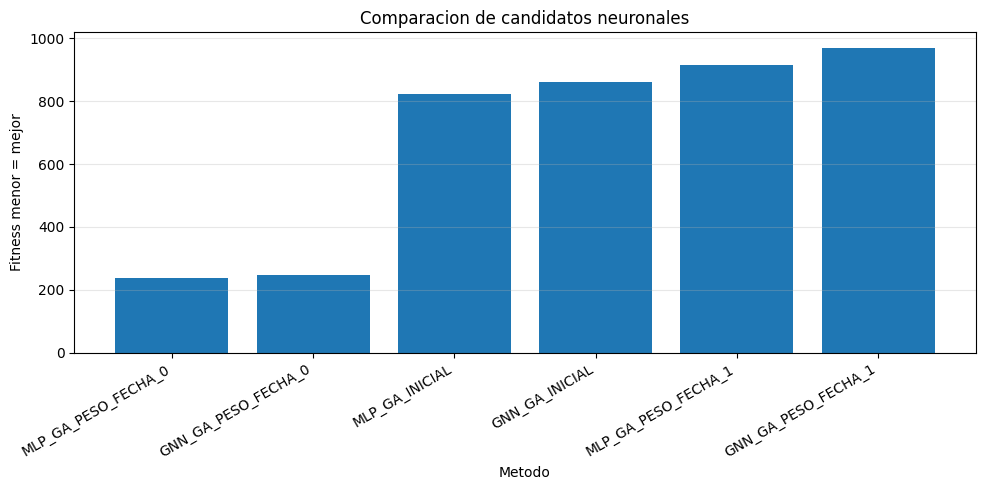

Gantt guardado en: /opt/projects/tfm/algoritmos/output/nn_gantt.png


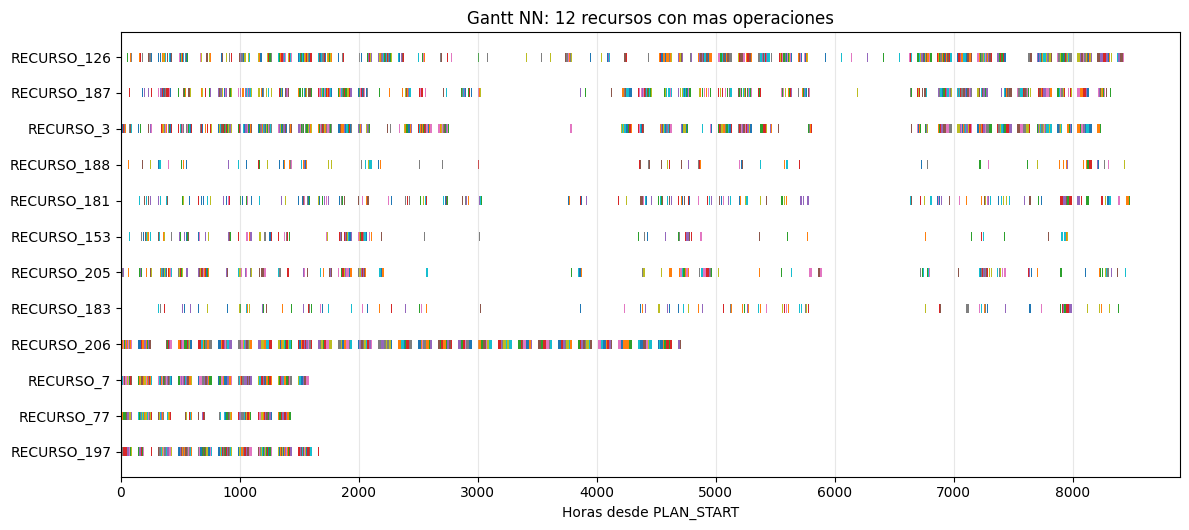

Gantt de maquinas extremas guardado en: /opt/projects/tfm/algoritmos/output/nn_gantt_extremos.png


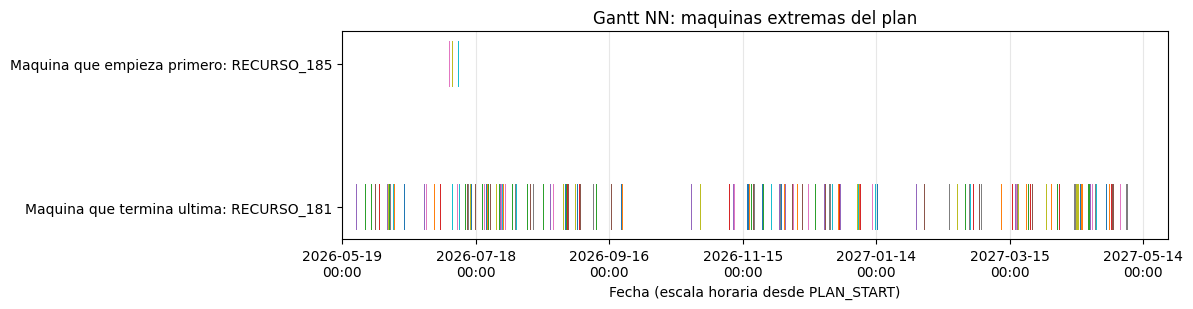

In [15]:
if len(logdf):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = logdf.sort_values("fitness")
    ax.bar(plot_df["metodo"], plot_df["fitness"])
    ax.set_xlabel("Metodo")
    ax.set_ylabel("Fitness menor = mejor")
    ax.set_title("Comparacion de candidatos neuronales")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    comparison_path = OUTPUT_DIR / "nn_comparacion_candidatos.png"
    plt.savefig(comparison_path, dpi=150, bbox_inches="tight")
    print("Grafico guardado en:", comparison_path)
    plt.show()

# Gantt de los recursos mas cargados.
if len(out_df):
    gantt_df = out_df.copy()
    gantt_df["RECURSO"] = gantt_df["RECURSO"].astype(str)
    gantt_df["COMIENZO_OPERACION_DT"] = pd.to_datetime(gantt_df["COMIENZO_OPERACION"])
    gantt_df["FIN_OPERACION_DT"] = pd.to_datetime(gantt_df["FIN_OPERACION"])

    def configurar_eje_horas_como_fechas(ax, inicio_plan, min_h, max_h):
        rango_h = max(float(max_h) - float(min_h), 1.0)
        pasos_h = [1, 2, 4, 8, 12, 24, 48, 72, 168, 336, 720, 1440]
        paso_h = next((p for p in pasos_h if rango_h / p <= 8), pasos_h[-1])
        tick_inicio = math.floor(float(min_h) / paso_h) * paso_h
        ticks = np.arange(tick_inicio, float(max_h) + paso_h, paso_h)
        ax.set_xticks(ticks)
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda h, _pos: (inicio_plan + pd.to_timedelta(float(h), unit="h")).strftime("%Y-%m-%d\n%H:%M")
            )
        )

    top_recursos = gantt_df.groupby("RECURSO").size().sort_values(ascending=False).head(12).index.tolist()
    sub = gantt_df[gantt_df["RECURSO"].isin(top_recursos)].copy()

    fig, ax = plt.subplots(figsize=(12, max(5, len(top_recursos) * 0.45)))
    y_map = {r: i for i, r in enumerate(reversed(top_recursos))}
    for _, row in sub.iterrows():
        y = y_map[row["RECURSO"]]
        start_h = (row["COMIENZO_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
        dur_h = (row["FIN_OPERACION_DT"] - row["COMIENZO_OPERACION_DT"]).total_seconds() / 3600.0
        ax.barh(y, max(dur_h, 0.01), left=start_h, height=0.25)
    ax.set_yticks(list(range(len(top_recursos))))
    ax.set_yticklabels(reversed(top_recursos))
    ax.set_xlabel("Horas desde PLAN_START")
    ax.set_title("Gantt NN: 12 recursos con mas operaciones")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    gantt_path = OUTPUT_DIR / "nn_gantt.png"
    plt.savefig(gantt_path, dpi=150, bbox_inches="tight")
    print("Gantt guardado en:", gantt_path)
    plt.show()

    recurso_primero = gantt_df.loc[gantt_df["COMIENZO_OPERACION_DT"].idxmin(), "RECURSO"]
    recurso_ultimo = gantt_df.loc[gantt_df["FIN_OPERACION_DT"].idxmax(), "RECURSO"]
    recursos_extremos = [
        ("Maquina que empieza primero", recurso_primero),
        ("Maquina que termina ultima", recurso_ultimo),
    ]

    fig, ax = plt.subplots(figsize=(12, 3.2))
    min_h, max_h = math.inf, -math.inf
    for y, (_rol, recurso) in enumerate(recursos_extremos):
        sub_extremo = gantt_df[gantt_df["RECURSO"] == recurso].sort_values("COMIENZO_OPERACION_DT")
        for _, row in sub_extremo.iterrows():
            start_h = (row["COMIENZO_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
            end_h = (row["FIN_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
            dur_h = end_h - start_h
            min_h = min(min_h, start_h)
            max_h = max(max_h, end_h)
            ax.barh(y, max(dur_h, 0.01), left=start_h, height=0.32)

    ax.set_yticks(list(range(len(recursos_extremos))))
    ax.set_yticklabels([f"{rol}: {recurso}" for rol, recurso in recursos_extremos])
    ax.invert_yaxis()
    configurar_eje_horas_como_fechas(ax, PLAN_START, min_h, max_h)
    ax.set_xlabel("Fecha (escala horaria desde PLAN_START)")
    ax.set_title("Gantt NN: maquinas extremas del plan")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    gantt_extremos_path = OUTPUT_DIR / "nn_gantt_extremos.png"
    plt.savefig(gantt_extremos_path, dpi=150, bbox_inches="tight")
    print("Gantt de maquinas extremas guardado en:", gantt_extremos_path)
    plt.show()


## Conclusion tecnica

La planificacion neuronal es valida si la celda de validacion devuelve `valido = True`.

Artefactos principales:

- `nn_resultados.csv`: plan exportado con formato equivalente a LPA.
- `nn_comparativa_metricas.csv`: comparacion de candidatos neuronales y heuristicas base.
- `nn_duracion_fija_metricas.csv`: trazabilidad de la duracion fija CCP usada.
- `nn_modelo_riesgo_metricas.csv`: metricas del modelo GNN de riesgo.
- `nn_duraciones_fijas_operacion.csv`: duraciones de operacion calculadas con la misma formula fija que `aps_ensemble.ipynb`.
- `nn_prioridades.csv`: tabla de features, rankings y score de prioridad por orden.
- `nn_metricas_por_orden.csv` y `nn_metricas_por_recurso.csv`: analisis detallado.


## 16. Analisis de politica GNN y duraciones fijas


In [16]:
print("Top 20 prioridades NN/GNN")
display(prioridades_df.head(20))

print("Trazabilidad de duracion fija")
display(modelo_duracion_metricas_df)

print("Metricas de la red de prioridad supervisada por GA")
display(modelo_riesgo_metricas_df)

print("Muestra de duraciones fijas de operacion")
display(duraciones_operacion_df.head(20))



Top 20 prioridades NN/GNN


,oidx,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,FECHA_PROVEEDOR,deadline_work_min,work_min,slack_min,cr,n_alternativas,n_grupos_recurso,duracion_media_operacion_min,duracion_max_operacion_min,operacion_min,operacion_max,log_cantidad,log_work_min,log_deadline_work_min,slack_relativo,log_cr,ga_rank_target,nn_priority_score,escenario_objetivo_ga,modelo_prioridad
0,0,ORDEN_7,PARTNUMBER_7,8.0,6,2026-06-15,27360.0,1353.654908,26006.345092,20.211946,6,5,225.609151,1159.537261,900020,1300020,2.197225,7.211302,10.216874,19.211946,3.054565,0.457241,0.512738,inicial,TorchGCN_prioridad_desde_GA
1,1,ORDEN_25,PARTNUMBER_20,29.0,3,2026-08-12,87840.0,1598.686162,86241.313838,54.945118,3,2,532.895387,807.835986,1000020,1000040,3.401197,7.377563,11.383284,20.000000,4.024371,0.520842,0.432567,inicial,TorchGCN_prioridad_desde_GA
2,2,ORDEN_57,PARTNUMBER_56,30.0,3,2026-06-20,34560.0,1691.089542,32868.910458,20.436529,3,3,563.696514,1277.777778,1000010,1000030,3.433987,7.433719,10.450481,19.436529,3.065096,0.545337,0.538261,inicial,TorchGCN_prioridad_desde_GA
3,3,ORDEN_63,PARTNUMBER_61,20.0,4,2026-06-06,20160.0,1092.393434,19067.606566,18.454889,4,3,273.098358,609.678649,900020,1300020,3.044522,6.997041,9.911505,17.454889,2.968098,0.375591,0.395228,inicial,TorchGCN_prioridad_desde_GA
4,4,ORDEN_71,PARTNUMBER_69,48.0,6,2026-06-16,28800.0,1256.404954,27543.595046,22.922546,9,7,209.400826,666.800000,900020,1300020,3.891820,7.136805,10.268165,20.000000,3.174821,0.426300,0.418030,inicial,TorchGCN_prioridad_desde_GA
5,5,ORDEN_72,PARTNUMBER_70,16.0,5,2026-06-30,43200.0,7465.286171,35734.713829,5.786784,5,4,1493.057234,6695.874407,900020,1300020,2.833213,8.918153,10.673619,4.786784,1.914977,0.936829,0.899351,inicial,TorchGCN_prioridad_desde_GA
6,6,ORDEN_73,PARTNUMBER_71,64.0,1,2026-06-27,41760.0,426.666667,41333.333333,97.875000,4,1,426.666667,426.666667,400020,400020,4.174387,6.058344,10.639718,20.000000,4.593856,0.153846,0.302661,inicial,TorchGCN_prioridad_desde_GA
7,7,ORDEN_76,PARTNUMBER_74,12.0,2,2026-05-20,1440.0,2307.476456,-867.476456,0.624058,2,1,1153.738228,1798.642534,800020,800030,2.564949,7.744343,7.273093,-0.375942,0.484928,0.679416,0.660280,inicial,TorchGCN_prioridad_desde_GA
8,8,ORDEN_77,PARTNUMBER_75,34.0,6,2026-08-01,77760.0,888.032143,76871.967857,87.564398,6,6,148.005357,402.222222,800020,1200020,3.555348,6.790133,11.261395,20.000000,4.483730,0.322303,0.303106,inicial,TorchGCN_prioridad_desde_GA
9,9,ORDEN_78,PARTNUMBER_76,10.0,3,2026-05-25,5760.0,325.044123,5434.955877,17.720671,3,2,108.348041,214.627703,900020,900040,2.397895,5.787033,8.658866,16.720671,2.929628,0.139235,0.147708,inicial,TorchGCN_prioridad_desde_GA


Trazabilidad de duracion fija


,modelo,tipo_duracion,formula_duracion,filas_operacion,entrenamiento_duracion,diferencia_formula_abs_max
0,CCP_formula_fija,CCP_formula_fija,(TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTI...,11166,False,1.818989e-12


Metricas de la red de prioridad supervisada por GA


,modelo,escenario,target,usa_lpa_como_target,usa_reglas_deterministas_como_candidatos,filas_train,features,hidden_layers,max_iter,mae_rank_normalizado_in_sample,r2_rank_in_sample,secuencia_ga_len,gnn_hidden_units,gnn_epochs,gnn_lr,train_loss_final,nodos_grafo,aristas_grafo
0,MLPRegressor_prioridad_desde_GA,inicial,ranking_normalizado_secuencia_GA,False,False,2328,"[log_cantidad, N_OPERACIONES, log_work_min, lo...","[64, 32]",700.0,0.012649,0.994627,2328,NaN,NaN,NaN,NaN,NaN,NaN
1,TorchGCN_prioridad_desde_GA,inicial,ranking_normalizado_secuencia_GA,False,False,2328,"[log_cantidad, N_OPERACIONES, log_work_min, lo...",NaN,NaN,0.048919,0.936694,2328,48.0,260.0,0.01,0.005290,3960.0,91188.0
2,MLPRegressor_prioridad_desde_GA,peso_fecha_1,ranking_normalizado_secuencia_GA,False,False,2328,"[log_cantidad, N_OPERACIONES, log_work_min, lo...","[64, 32]",700.0,0.014028,0.990334,2328,NaN,NaN,NaN,NaN,NaN,NaN
3,TorchGCN_prioridad_desde_GA,peso_fecha_1,ranking_normalizado_secuencia_GA,False,False,2328,"[log_cantidad, N_OPERACIONES, log_work_min, lo...",NaN,NaN,0.050907,0.930609,2328,48.0,260.0,0.01,0.005816,3960.0,91188.0
4,MLPRegressor_prioridad_desde_GA,peso_fecha_0,ranking_normalizado_secuencia_GA,False,False,2328,"[log_cantidad, N_OPERACIONES, log_work_min, lo...","[64, 32]",700.0,0.240863,0.048438,2328,NaN,NaN,NaN,NaN,NaN,NaN
5,TorchGCN_prioridad_desde_GA,peso_fecha_0,ranking_normalizado_secuencia_GA,False,False,2328,"[log_cantidad, N_OPERACIONES, log_work_min, lo...",NaN,NaN,0.246995,0.020483,2328,48.0,260.0,0.01,0.081710,3960.0,91188.0


Muestra de duraciones fijas de operacion


,oidx,ORDEN,PARTNUMBER,OPERACION,GRUPO_RECURSO,CCP_RECURSO,CANTIDAD,TIEMPO_FIJO_MIN,TIEMPO_VARIABLE_MIN,MULTIPLICIDAD,OEE,tiempo_proceso_sin_oee_min,duracion_base_sin_oee_min,duracion_fija_ccp_min,duracion_formula_min,diferencia_formula_min
0,0,ORDEN_7,PARTNUMBER_7,900020,GRUPO_RECURSO_104,RECURSO_76,8.0,30.0,104.00,1,74.34,832.000000,862.000000,1159.537261,1159.537261,0.000000e+00
1,0,ORDEN_7,PARTNUMBER_7,900030,GRUPO_RECURSO_43,RECURSO_8,8.0,1.0,1.00,1,85.00,8.000000,9.000000,10.588235,10.588235,0.000000e+00
2,0,ORDEN_7,PARTNUMBER_7,900040,GRUPO_RECURSO_43,RECURSO_9,8.0,5.0,9.00,1,85.00,72.000000,77.000000,90.588235,90.588235,0.000000e+00
3,0,ORDEN_7,PARTNUMBER_7,900050,GRUPO_RECURSO_24,RECURSO_24,8.0,5.0,1.00,1,85.00,8.000000,13.000000,15.294118,15.294118,0.000000e+00
4,0,ORDEN_7,PARTNUMBER_7,900060,GRUPO_RECURSO_11,RECURSO_11,8.0,5.0,1.00,1,85.00,8.000000,13.000000,15.294118,15.294118,0.000000e+00
5,0,ORDEN_7,PARTNUMBER_7,1300020,GRUPO_RECURSO_4,RECURSO_4,8.0,5.0,6.00,1,85.00,48.000000,53.000000,62.352941,62.352941,0.000000e+00
6,1,ORDEN_25,PARTNUMBER_20,1000020,GRUPO_RECURSO_14,RECURSO_55,29.0,30.0,20.33,1,85.74,589.570000,619.570000,722.614882,722.614882,0.000000e+00
7,1,ORDEN_25,PARTNUMBER_20,1000030,GRUPO_RECURSO_14,RECURSO_55,29.0,30.0,24.17,1,90.48,700.930000,730.930000,807.835986,807.835986,2.273737e-13
8,1,ORDEN_25,PARTNUMBER_20,1000040,GRUPO_RECURSO_43,RECURSO_126,29.0,0.0,2.00,1,85.00,58.000000,58.000000,68.235294,68.235294,0.000000e+00
9,2,ORDEN_57,PARTNUMBER_56,1000010,GRUPO_RECURSO_65,RECURSO_104,30.0,0.0,9.33,1,100.00,279.900000,279.900000,279.900000,279.900000,0.000000e+00


## 17. Analisis ampliado por orden y por recurso

In [17]:
# Metricas por orden.
workload_by_order_min = defaultdict(float)
for s in best_sch:
    workload_by_order_min[s["oidx"]] += max(0.0, s["t_end"] - s["t_start"])

order_rows = []
finish_by_order = {idx: finish for idx, finish in best_of.items()}
for idx, od in nn_order_operations.items():
    finish_min = finish_by_order.get(idx, math.inf)
    if math.isfinite(finish_min):
        finish_dt = fecha_plan_desde_minutos_laborales(finish_min)
    else:
        finish_dt = pd.NaT
    deadline = pd.Timestamp(od["deadline"]) if pd.notna(od["deadline"]) else pd.NaT
    deadline_work_min = od.get("deadline_work_min", math.inf)
    late_min = max(0.0, float(finish_min) - float(deadline_work_min)) if math.isfinite(finish_min) and math.isfinite(deadline_work_min) else math.inf
    order_rows.append({
        "ORDEN": od["orden"],
        "PARTNUMBER": od["pn"],
        "CANTIDAD": od["qty"],
        "N_OPERACIONES": od["n_ops"],
        "CARGA_TRABAJO_HORAS": workload_by_order_min.get(idx, 0.0) / 60.0,
        "FECHA_PROVEEDOR": deadline,
        "FIN_PLANIFICADO": finish_dt,
        "TARDANZA_MIN": late_min,
        "TARDANZA_DIAS": late_min / max(MINUTOS_TRABAJO_DIA, 1.0) if math.isfinite(late_min) else math.inf,
        "A_TIEMPO": bool(late_min <= 0),
    })

orden_metricas_df = pd.DataFrame(order_rows).sort_values(["A_TIEMPO", "TARDANZA_MIN"], ascending=[True, False])
orden_metricas_path = OUTPUT_DIR / "nn_metricas_por_orden.csv"
orden_metricas_df.to_csv(orden_metricas_path, sep=";", index=False)

ordenes_fuera_fecha_df = orden_metricas_df[~orden_metricas_df["A_TIEMPO"]].copy()
ordenes_fuera_fecha_path = OUTPUT_DIR / "nn_ordenes_fuera_fecha.csv"
ordenes_fuera_fecha_df.to_csv(ordenes_fuera_fecha_path, sep=";", index=False)

carga_total_horas = orden_metricas_df["CARGA_TRABAJO_HORAS"].sum()
carga_en_fecha_horas = orden_metricas_df.loc[orden_metricas_df["A_TIEMPO"], "CARGA_TRABAJO_HORAS"].sum()
ordenes_totales = len(orden_metricas_df)
ordenes_en_fecha = int(orden_metricas_df["A_TIEMPO"].sum())
metricas_cumplimiento_fechas_df = pd.DataFrame([{
    "ordenes_totales": ordenes_totales,
    "ordenes_en_fecha": ordenes_en_fecha,
    "ordenes_fuera_fecha": int(len(ordenes_fuera_fecha_df)),
    "porcentaje_ordenes_en_fecha": (ordenes_en_fecha / ordenes_totales * 100.0) if ordenes_totales else 0.0,
    "carga_total_horas": carga_total_horas,
    "carga_en_fecha_horas": carga_en_fecha_horas,
    "carga_fuera_fecha_horas": carga_total_horas - carga_en_fecha_horas,
    "porcentaje_carga_horas_en_fecha": (carga_en_fecha_horas / carga_total_horas * 100.0) if carga_total_horas else 0.0,
}])
metricas_cumplimiento_fechas_path = OUTPUT_DIR / "nn_metricas_cumplimiento_fechas.csv"
metricas_cumplimiento_fechas_df.to_csv(metricas_cumplimiento_fechas_path, sep=";", index=False)

print("Metricas por orden guardadas en:", orden_metricas_path)
print("Ordenes fuera de fecha guardadas en:", ordenes_fuera_fecha_path)
print("Metricas de cumplimiento de fechas guardadas en:", metricas_cumplimiento_fechas_path)
display(metricas_cumplimiento_fechas_df)
display(orden_metricas_df.head(20))
display(ordenes_fuera_fecha_df.head(20))

# Metricas por recurso.
res_df = out_df.copy()
res_df["COMIENZO_OPERACION_DT"] = pd.to_datetime(res_df["COMIENZO_OPERACION"])
res_df["FIN_OPERACION_DT"] = pd.to_datetime(res_df["FIN_OPERACION"])
res_df["DURACION_MIN"] = (res_df["FIN_OPERACION_DT"] - res_df["COMIENZO_OPERACION_DT"]).dt.total_seconds() / 60.0
makespan_min = best_met["makespan_min"]
recurso_metricas_df = (
    res_df.groupby(["GRUPO_RECURSO", "RECURSO"], as_index=False)
    .agg(
        operaciones=("ORDEN", "count"),
        carga_min=("DURACION_MIN", "sum"),
        comienzo=("COMIENZO_OPERACION_DT", "min"),
        fin=("FIN_OPERACION_DT", "max"),
    )
)
recurso_metricas_df["utilizacion_sobre_makespan"] = recurso_metricas_df["carga_min"] / makespan_min
recurso_metricas_df = recurso_metricas_df.sort_values("carga_min", ascending=False)
recurso_metricas_path = OUTPUT_DIR / "nn_metricas_por_recurso.csv"
recurso_metricas_df.to_csv(recurso_metricas_path, sep=";", index=False)
print("Metricas por recurso guardadas en:", recurso_metricas_path)
display(recurso_metricas_df.head(20))


Metricas por orden guardadas en: /opt/projects/tfm/algoritmos/output/nn_metricas_por_orden.csv
Ordenes fuera de fecha guardadas en: /opt/projects/tfm/algoritmos/output/nn_ordenes_fuera_fecha.csv
Metricas de cumplimiento de fechas guardadas en: /opt/projects/tfm/algoritmos/output/nn_metricas_cumplimiento_fechas.csv


,ordenes_totales,ordenes_en_fecha,ordenes_fuera_fecha,porcentaje_ordenes_en_fecha,carga_total_horas,carga_en_fecha_horas,carga_fuera_fecha_horas,porcentaje_carga_horas_en_fecha
0,2328,1026,1302,44.072165,94616.591094,17319.09475,77297.496344,18.304501


,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,CARGA_TRABAJO_HORAS,FECHA_PROVEEDOR,FIN_PLANIFICADO,TARDANZA_MIN,TARDANZA_DIAS,A_TIEMPO
1881,ORDEN_11935,PARTNUMBER_1510,495.0,5,441.608982,2026-05-19,2027-04-28 09:31:32.074473048,354811.534575,246.396899,False
485,ORDEN_3964,PARTNUMBER_2769,6.0,10,221.249238,2026-05-22,2027-04-29 00:10:21.486237756,351370.358104,244.007193,False
737,ORDEN_5549,PARTNUMBER_1316,16.0,9,142.073934,2026-05-22,2027-04-27 21:05:03.839178930,349745.063986,242.878517,False
321,ORDEN_2789,PARTNUMBER_152,37.0,8,127.206174,2026-05-20,2027-04-23 02:34:37.172512266,348634.619542,242.107375,False
432,ORDEN_3521,PARTNUMBER_2516,8.0,13,201.884645,2026-05-30,2027-05-03 17:03:16.971896160,346623.282865,240.710613,False
1444,ORDEN_9209,PARTNUMBER_1932,6.0,12,243.994982,2026-05-25,2027-04-22 17:17:18.819571086,343757.313660,238.720357,False
360,ORDEN_3107,PARTNUMBER_2272,14.0,9,214.451909,2026-05-26,2027-04-21 10:57:32.937218148,340497.548954,236.456631,False
526,ORDEN_4278,PARTNUMBER_2606,24.0,6,154.056028,2026-05-26,2027-04-21 07:23:28.026749670,340283.467112,236.307963,False
306,ORDEN_2636,PARTNUMBER_1939,7.0,11,257.030343,2026-06-08,2027-05-03 20:46:10.233928254,339646.170565,235.865396,False
1613,ORDEN_10002,PARTNUMBER_1020,48.0,9,164.230854,2026-06-02,2027-04-26 16:07:23.791455552,337927.396524,234.671803,False


,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,CARGA_TRABAJO_HORAS,FECHA_PROVEEDOR,FIN_PLANIFICADO,TARDANZA_MIN,TARDANZA_DIAS,A_TIEMPO
1881,ORDEN_11935,PARTNUMBER_1510,495.0,5,441.608982,2026-05-19,2027-04-28 09:31:32.074473048,354811.534575,246.396899,False
485,ORDEN_3964,PARTNUMBER_2769,6.0,10,221.249238,2026-05-22,2027-04-29 00:10:21.486237756,351370.358104,244.007193,False
737,ORDEN_5549,PARTNUMBER_1316,16.0,9,142.073934,2026-05-22,2027-04-27 21:05:03.839178930,349745.063986,242.878517,False
321,ORDEN_2789,PARTNUMBER_152,37.0,8,127.206174,2026-05-20,2027-04-23 02:34:37.172512266,348634.619542,242.107375,False
432,ORDEN_3521,PARTNUMBER_2516,8.0,13,201.884645,2026-05-30,2027-05-03 17:03:16.971896160,346623.282865,240.710613,False
1444,ORDEN_9209,PARTNUMBER_1932,6.0,12,243.994982,2026-05-25,2027-04-22 17:17:18.819571086,343757.313660,238.720357,False
360,ORDEN_3107,PARTNUMBER_2272,14.0,9,214.451909,2026-05-26,2027-04-21 10:57:32.937218148,340497.548954,236.456631,False
526,ORDEN_4278,PARTNUMBER_2606,24.0,6,154.056028,2026-05-26,2027-04-21 07:23:28.026749670,340283.467112,236.307963,False
306,ORDEN_2636,PARTNUMBER_1939,7.0,11,257.030343,2026-06-08,2027-05-03 20:46:10.233928254,339646.170565,235.865396,False
1613,ORDEN_10002,PARTNUMBER_1020,48.0,9,164.230854,2026-06-02,2027-04-26 16:07:23.791455552,337927.396524,234.671803,False


Metricas por recurso guardadas en: /opt/projects/tfm/algoritmos/output/nn_metricas_por_recurso.csv


,GRUPO_RECURSO,RECURSO,operaciones,carga_min,comienzo,fin,utilizacion_sobre_makespan
116,GRUPO_RECURSO_43,RECURSO_126,1582,197771.600000,2026-05-19 00:10:19,2027-05-05 05:59:45,0.542228
127,GRUPO_RECURSO_50,RECURSO_206,261,196790.366667,2026-05-19 03:49:00,2026-12-01 01:08:34,0.539538
4,GRUPO_RECURSO_1,RECURSO_3,921,196490.833333,2026-05-19 00:36:00,2027-04-27 09:41:03,0.538717
51,GRUPO_RECURSO_137,RECURSO_96,157,158750.966667,2026-05-21 14:22:59,2026-10-29 23:33:19,0.435246
40,GRUPO_RECURSO_128,RECURSO_139,79,100786.500000,2026-05-21 06:48:09,2026-09-21 02:25:13,0.276325
83,GRUPO_RECURSO_2,RECURSO_99,139,100698.616667,2026-05-19 00:00:00,2026-08-27 00:37:02,0.276084
80,GRUPO_RECURSO_2,RECURSO_179,162,100671.350000,2026-05-19 00:00:00,2026-09-14 17:08:30,0.276010
82,GRUPO_RECURSO_2,RECURSO_192,145,97914.833333,2026-05-19 00:00:00,2026-08-28 11:16:06,0.268452
108,GRUPO_RECURSO_4,RECURSO_181,518,93385.383333,2026-05-19 00:00:00,2027-05-07 06:58:35,0.256034
81,GRUPO_RECURSO_2,RECURSO_180,135,92624.916667,2026-05-19 00:00:00,2026-08-28 16:42:28,0.253949


## 18. Resumen trazable del experimento

In [18]:
# Resumen de experimento en JSON para trazabilidad.
def resumen_operacion_planificada(op, instante):
    if op is None:
        return None
    campo_minuto = "t_start" if instante == "inicio" else "t_end"
    campo_fecha = "fecha_hora_inicio" if instante == "inicio" else "fecha_hora_fin"
    campo_minuto_resumen = "minuto_laboral_inicio" if instante == "inicio" else "minuto_laboral_fin"
    fecha = fecha_plan_desde_minutos_laborales(op[campo_minuto], como_fin=(instante == "fin"))
    return {
        campo_fecha: fmt_ts(fecha),
        "recurso": str(op["RECURSO"]),
        "grupo_recurso": str(op["GRUPO_RECURSO"]),
        "orden": str(op["ORDEN"]),
        "operacion": int(op["OPERACION"]),
        "partnumber": str(op["PARTNUMBER"]),
        campo_minuto_resumen: float(op[campo_minuto]),
        "duracion_minutos": round(float(op["t_end"] - op["t_start"]), 6),
    }

primera_operacion = None
ultima_operacion = None
if best_sch:
    primera_operacion = min(
        best_sch,
        key=lambda s: (s["t_start"], s["t_end"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
    )
    ultima_operacion = max(
        best_sch,
        key=lambda s: (s["t_end"], s["t_start"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
    )

primera_operacion_planificada = resumen_operacion_planificada(primera_operacion, "inicio")
ultima_operacion_planificada = resumen_operacion_planificada(ultima_operacion, "fin")

experimento = {
    "nombre": "aps_neuronal",
    "root_dir": str(ROOT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plan_start": str(PLAN_START),
    "random_seed": RANDOM_SEED,
    "parametros_nn": {
        "PESO_FECHA": PESO_FECHA,
        "DURACION_FORMULA_CCP": DURACION_FORMULA_CCP,
        "GA_SECUENCIAS_PATH": str(GA_SECUENCIAS_PATH),
        "ESCENARIO_NN_PRINCIPAL": ESCENARIO_NN_PRINCIPAL,
        "NN_HIDDEN_LAYERS": NN_HIDDEN_LAYERS,
        "NN_MAX_ITER": NN_MAX_ITER,
        "GNN_HIDDEN_UNITS": GNN_HIDDEN_UNITS,
        "GNN_EPOCHS": GNN_EPOCHS,
        "GNN_LR": GNN_LR,
        "SUPERVISION": "secuencias_oidx_ganadoras_del_algoritmo_genetico",
        "USA_LPA_COMO_TARGET": False,
        "USA_REGLAS_DETERMINISTAS_COMO_CANDIDATOS": False,
        "HORAS_TRABAJO_DIA": HORAS_TRABAJO_DIA,
        "TRABAJA_FINES_SEMANA": TRABAJA_FINES_SEMANA,
        "HORA_INICIO_TURNO": HORA_INICIO_TURNO,
        "MODO_PLANIFICACION_ORDENES": MODO_PLANIFICACION_ORDENES,
        "ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA": ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA,
    },
    "datos": {
        "ordenes_plan_originales": n_plan_original,
        "ordenes_fuera_lpa": n_ordenes_plan_fuera_lpa,
        "ordenes_descartadas_por_modo_lpa": len(ordenes_plan_fuera_lpa),
        "ordenes_planificables": len(nn_order_operations),
        "ordenes_omitidas": len(skipped_orders),
        "segmentos_planificados": int(len(out_df)),
        "operaciones_planificadas_unicas": int(out_df[["ORDEN", "OPERACION"]].drop_duplicates().shape[0]),
        "recursos": int(recursos_df["RECURSO"].nunique()),
        "grupos_recurso": int(recursos_df["GRUPO_RECURSO"].nunique()),
    },
    "duracion": {"tipo": "CCP_formula_fija", "formula": DURACION_FORMULA_CCP},
    "ventana_planificada": {
        "unidad_tiempos_schedule": "minutos_laborales",
        "primera_operacion": primera_operacion_planificada,
        "ultima_operacion": ultima_operacion_planificada,
    },
    "duracion_fija_metricas": modelo_duracion_metricas_df.to_dict(orient="records"),
    "modelo_prioridad_ga_metricas": modelo_riesgo_metricas_df.to_dict(orient="records"),
    "mejor_metricas": best_met,
    "validacion": validation,
}
experimento_path = OUTPUT_DIR / "nn_resumen_experimento_aps.json"
with open(experimento_path, "w", encoding="utf-8") as f:
    json.dump(experimento, f, ensure_ascii=False, indent=2, default=str)
print("Resumen de experimento guardado en:", experimento_path)

print("\n" + "="*60)
print("METRICAS GENERALES DEL EXPERIMENTO NEURONAL")
print("="*60)
tiempo_ejecucion = best_met.get('tiempo_ejecucion_nn_min', 0.0)
print(f"Tiempo de ejecucion del algoritmo: {tiempo_ejecucion:.2f} minutos")

pct_ordenes_en_fecha = best_met.get('on_time_rate', 0.0) * 100
print(f"Porcentaje de ordenes completadas en fecha: {pct_ordenes_en_fecha:.2f}%")

pct_carga_en_fecha = best_met.get('on_time_workload_rate', 0.0) * 100
print(f"Porcentaje de carga de trabajo completado en fecha: {pct_carga_en_fecha:.2f}%")

if primera_operacion_planificada is not None:
    print(
        "Primera operacion planificada: "
        f"{primera_operacion_planificada['fecha_hora_inicio']} "
        f"en recurso {primera_operacion_planificada['recurso']}"
    )
if ultima_operacion_planificada is not None:
    print(
        "Fin de la ultima operacion planificada: "
        f"{ultima_operacion_planificada['fecha_hora_fin']} "
        f"en recurso {ultima_operacion_planificada['recurso']}"
    )





Resumen de experimento guardado en: /opt/projects/tfm/algoritmos/output/nn_resumen_experimento_aps.json

METRICAS GENERALES DEL EXPERIMENTO NEURONAL
Tiempo de ejecucion del algoritmo: 0.16 minutos
Porcentaje de ordenes completadas en fecha: 44.07%
Porcentaje de carga de trabajo completado en fecha: 18.30%
Primera operacion planificada: 2026-05-19 00:00:00.000 en recurso RECURSO_56
Fin de la ultima operacion planificada: 2027-05-07 06:58:35.000 en recurso RECURSO_181


In [19]:
# JSON comparativo: politica neuronal supervisada por el GA en los tres escenarios.
def preparar_metricas_comparacion(metricas):
    if metricas is None:
        return None
    excluir = {"best_chrom", "chromosome", "schedule"}
    return {k: v for k, v in metricas.items() if k not in excluir}


log_por_escenario = {}
for _, row in logdf.iterrows():
    escenario = str(row["escenario_objetivo_ga"])
    variante = str(row.get("variante_nn", "NN"))
    log_por_escenario.setdefault(escenario, {})[variante] = row.to_dict()


def preparar_simulacion_nn(nombre, escenario, peso_fecha, parametros_extra=None):
    variantes = {
        variante: preparar_metricas_comparacion(metricas)
        for variante, metricas in log_por_escenario.get(escenario, {}).items()
    }
    mejor_variante = None
    mejor_metricas = None
    for variante, metricas in variantes.items():
        if mejor_metricas is None or float(metricas.get("fitness", float("inf"))) < float(mejor_metricas.get("fitness", float("inf"))):
            mejor_variante = variante
            mejor_metricas = metricas
    return {
        "nombre": nombre,
        "peso_fecha": float(peso_fecha),
        "mejor_variante_nn": mejor_variante,
        "best_score": mejor_metricas.get("fitness") if mejor_metricas else None,
        "fitness_ga_teacher": mejor_metricas.get("fitness_ga_teacher") if mejor_metricas else None,
        "escenario_objetivo_ga": escenario,
        "metricas": mejor_metricas,
        "variantes": variantes,
        "ventana_planificada": None if escenario != ESCENARIO_NN_PRINCIPAL else experimento.get("ventana_planificada", {}),
        "operaciones_sin_planificar": (mejor_metricas or {}).get("missing_ops"),
        "parametros_extra": parametros_extra or {},
    }


resumen_comparativo = {
    "nombre": "aps_neuronal_supervisado_ga",
    "archivo_origen": "aps_neuronal.ipynb",
    "descripcion": "Resumen comparable de MLP y GNN entrenadas para imitar las secuencias ganadoras del GA.",
    "root_dir": str(ROOT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plan_start": str(PLAN_START),
    "random_seed": RANDOM_SEED,
    "parametros": experimento.get("parametros_nn", {}),
    "datos": experimento.get("datos", {}),
    "validacion": experimento.get("validacion", {}),
    "duracion": experimento.get("duracion", {}),
    "modelo_prioridad_ga_metricas": modelo_riesgo_metricas_df.to_dict(orient="records"),
    "simulaciones": {
        "inicial": preparar_simulacion_nn(
            "inicial",
            "inicial",
            0.85,
            parametros_extra={"supervision": "secuencia GA inicial PESO_FECHA=0.85"},
        ),
        "peso_fecha_1": preparar_simulacion_nn(
            "peso_fecha_1",
            "peso_fecha_1",
            1.0,
            parametros_extra={"supervision": "secuencia GA con solo objetivo de fechas"},
        ),
        "peso_fecha_0": preparar_simulacion_nn(
            "peso_fecha_0",
            "peso_fecha_0",
            0.0,
            parametros_extra={"supervision": "secuencia GA con solo objetivo de makespan"},
        ),
    },
}


comparativa_mlp_gnn = {
    "resumen": "La GNN aporta una comparacion estructural real contra la MLP, pero no domina globalmente en esta ejecucion.",
    "mejor_por_escenario": {},
    "conclusion": (
        "La MLP tabular funciona mejor en los escenarios orientados a fechas "
        "(PESO_FECHA=0.85 y PESO_FECHA=1.0). La GNN mejora a la MLP en el escenario "
        "de menor duracion total (PESO_FECHA=0.0), donde la estructura de relaciones entre "
        "ordenes, operaciones y grupos de recurso parece aportar mas informacion sobre cuellos de botella."
    ),
    "interpretacion": {
        "MLP": "Aprende el ranking GA desde variables agregadas por orden; es mas fuerte en los escenarios de fecha/tardanza.",
        "GNN": "Aprende el ranking GA usando tambien la estructura orden-partnumber-operacion-grupo; mejora en el objetivo de makespan.",
    },
}
for escenario, sim in resumen_comparativo["simulaciones"].items():
    variantes = sim.get("variantes", {}) or {}
    if not variantes:
        continue
    mejor_variante, mejor_metricas = min(
        variantes.items(),
        key=lambda kv: float(kv[1].get("fitness", float("inf"))),
    )
    comparativa_mlp_gnn["mejor_por_escenario"][escenario] = {
        "mejor_variante": mejor_variante,
        "fitness": mejor_metricas.get("fitness"),
        "fitness_ga_teacher": sim.get("fitness_ga_teacher"),
        "diferencia_vs_ga": None if sim.get("fitness_ga_teacher") is None else mejor_metricas.get("fitness") - sim.get("fitness_ga_teacher"),
        "tardy_orders": mejor_metricas.get("tardy_orders"),
        "makespan_days": mejor_metricas.get("makespan_days"),
        "on_time_rate": mejor_metricas.get("on_time_rate"),
        "on_time_workload_rate": mejor_metricas.get("on_time_workload_rate"),
    }
resumen_comparativo["comparativa_mlp_gnn"] = comparativa_mlp_gnn

resumen_comparativo_path = OUTPUT_DIR / "nn_resumen_comparativo_simulaciones.json"
with open(resumen_comparativo_path, "w", encoding="utf-8") as f:
    json.dump(resumen_comparativo, f, ensure_ascii=False, indent=2, default=str)

print("Resumen comparativo neuronal guardado en:", resumen_comparativo_path)




Resumen comparativo neuronal guardado en: /opt/projects/tfm/algoritmos/output/nn_resumen_comparativo_simulaciones.json


In [20]:
# Comparativa final MLP vs GNN supervisadas por GA.
def imprimir_comparativa_mlp_gnn(logdf):
    etiquetas = OrderedDict([
        ("inicial", "PESO_FECHA = 0.85"),
        ("peso_fecha_1", "PESO_FECHA = 1.00"),
        ("peso_fecha_0", "PESO_FECHA = 0.00"),
    ])

    print("\n" + "="*72)
    print("COMPARATIVA FINAL NN: MLP TABULAR VS GNN SUPERVISADAS POR GA")
    print("="*72)
    for escenario, etiqueta in etiquetas.items():
        sub = logdf[logdf["escenario_objetivo_ga"] == escenario].copy()
        if not len(sub):
            continue
        sub = sub.sort_values("fitness").reset_index(drop=True)
        best = sub.iloc[0]
        teacher = float(best.get("fitness_ga_teacher", 0.0))

        print("\n" + "-"*72)
        print(f"Escenario {etiqueta} | GA profesor fitness={teacher:.4f}")
        print("-"*72)
        for _, row in sub.iterrows():
            variante = row.get("variante_nn", row.get("metodo", "NN"))
            fitness = float(row.get("fitness", 0.0))
            diff_teacher = fitness - teacher
            print(
                f"{variante:>4s} | metodo={row.get('metodo'):22s} "
                f"fitness={fitness:10.4f} "
                f"diff_GA={diff_teacher:9.4f} "
                f"tardy={int(row.get('tardy_orders', 0)):4d} "
                f"on_time={float(row.get('on_time_rate', 0.0))*100:6.2f}% "
                f"carga_fecha={float(row.get('on_time_workload_rate', 0.0))*100:6.2f}% "
                f"makespan_d={float(row.get('makespan_days', 0.0)):7.2f}"
            )

        print(
            f"Mejor variante NN: {best.get('variante_nn')} "
            f"({best.get('metodo')}) con fitness={float(best.get('fitness', 0.0)):.4f}"
        )

    print("\n" + "="*72)
    print("LECTURA GLOBAL")
    print("="*72)
    print("La MLP tabular es mejor en los escenarios 0.85 y solo fechas.")
    print("La GNN es mejor que la MLP en el escenario de solo menor duracion total.")
    print("La GNN aporta una comparacion estructural real, pero no domina globalmente en esta ejecucion.")


imprimir_comparativa_mlp_gnn(logdf)




COMPARATIVA FINAL NN: MLP TABULAR VS GNN SUPERVISADAS POR GA

------------------------------------------------------------------------
Escenario PESO_FECHA = 0.85 | GA profesor fitness=798.3496
------------------------------------------------------------------------
 MLP | metodo=MLP_GA_INICIAL         fitness=  821.5048 diff_GA=  23.1552 tardy=1256 on_time= 46.05% carga_fecha= 18.32% makespan_d= 254.60
 GNN | metodo=GNN_GA_INICIAL         fitness=  860.4273 diff_GA=  62.0777 tardy=1302 on_time= 44.07% carga_fecha= 18.30% makespan_d= 253.29
Mejor variante NN: MLP (MLP_GA_INICIAL) con fitness=821.5048

------------------------------------------------------------------------
Escenario PESO_FECHA = 1.00 | GA profesor fitness=891.5891
------------------------------------------------------------------------
 MLP | metodo=MLP_GA_PESO_FECHA_1    fitness=  913.5608 diff_GA=  21.9718 tardy=1228 on_time= 47.25% carga_fecha= 19.41% makespan_d= 262.42
 GNN | metodo=GNN_GA_PESO_FECHA_1    fitness=

### Lectura final de la comparativa MLP vs GNN

La GNN ya aporta una comparacion real contra la MLP tabular porque ambas aprenden del mismo profesor, el algoritmo genetico, pero con representaciones distintas. La MLP ve cada orden como una fila de variables agregadas; la GNN ve ademas la estructura de relaciones entre orden, partnumber, operaciones y grupos de recurso.

En esta ejecucion, la GNN no domina globalmente. La MLP funciona mejor en el escenario principal `PESO_FECHA = 0.85` y en el escenario de solo fechas (`PESO_FECHA = 1.0`). En ambos casos se acerca mas al fitness del GA profesor y obtiene mejor fitness que la GNN. Esto sugiere que, para los objetivos donde pesan fechas/tardanza, las variables tabulares agregadas (`slack`, `cr`, carga CCP, numero de operaciones, alternativas, etc.) ya capturan bastante bien la estructura que el GA esta explotando.

La GNN si mejora a la MLP en el escenario de menor duracion total (`PESO_FECHA = 0.0`). Tiene sentido que ahi la estructura del grafo ayude mas: para reducir makespan importan mucho las conexiones entre ordenes, operaciones y grupos de recurso, porque esas conexiones aproximan mejor la competencia por capacidad y los posibles cuellos de botella que una fila tabular aislada.

Lectura rapida: la GNN ya aporta una comparacion real contra la MLP. De momento no domina globalmente, pero si mejora a la MLP en el escenario de menor duracion total. Por tanto, la GNN queda justificada como variante estructural prometedora, aunque en los resultados actuales la MLP sigue siendo la mejor politica neuronal para los escenarios orientados a fechas.



## Conclusion de la version neuronal

Este notebook implementa una politica neuronal de prioridad supervisada por el algoritmo genetico. Las duraciones de operacion se mantienen fijas por formula CCP igual que en `aps_genetico.ipynb`; la red no predice tiempos reales ni modifica `dur_total`, `TIEMPO_PREPARACION`, `TIEMPO_PROCESO` ni `DURACION_CCP`.

La red aprende a aproximar la posicion de cada orden en las secuencias ganadoras del GA para los escenarios `PESO_FECHA = 0.85`, `PESO_FECHA = 1.0` y `PESO_FECHA = 0.0`. Despues genera su propia permutacion de ordenes y se evalua con el mismo `decode_schedule`, lo que permite comparar la politica aprendida contra el profesor genetico usando las mismas restricciones duras y metricas.
